# Pre-SMAP vs SMAP-era Skill: MAT Obs vs ISMN Obs

This notebook reproduces the pre-SMAP / SMAP-era skill workflow for **surface soil moisture** and compares two observation sources:

- `MAT` observations from `INSITU_sm` in the raw GEOSldas `.mat` files
- `ISMN` observations mapped to the same model/MAT sites by nearest lat/lon (distance threshold)

The notebook computes site-level and aggregated metrics for `OL` and `DA` and compares results across observation source.


In [18]:
from pathlib import Path
import sys
import datetime as dt
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from ismn.interface import ISMN_Interface

%matplotlib inline

# -------------------------
# User configuration
# -------------------------
NETWORK = "USCRN"  # "USCRN" or "SCAN"
SMAP_ERA_END = "2024-06-01"  # "2021-04-01" or "2024-06-01"

BASE_DIR = Path("/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2")
ISMN_DATA_PATH = Path("/Users/amfox/Desktop/ISMN_data")

RAW_MAT_FILES = {
    "OL": BASE_DIR / f"LS_OLv8_M36_{NETWORK}_SM_1d_c1234smv_25yr_raw_timeseries.mat",
    "DA": BASE_DIR / f"LS_DAv8_M36_{NETWORK}_SM_1d_c1234smv_25yr_raw_timeseries.mat",
}

# Match and selection controls
MATCH_MAX_KM = 2.0
TARGET_SURFACE_DEPTH_M = 0.05
MIN_OBS_DAYS_PER_RANGE = 1000
TOP_N_COMMON_SITES = None  # set None to use all eligible common sites

# Skill settings (same style as existing notebook)
NMIN = 1000
NMIN_DAY = 30
ADD_ANOMR = True
EXP_ORDER = ["OL", "DA"]

# ISMN QC controls
ISMN_REQUIRED_SM_FLAG = "G"

# ISMN daily timestamp shift for visual/time alignment
ISMN_DAILY_SHIFT_HOURS = 12


# Root-zone (RZ) construction controls for observations (0-1 m)
RZ_TOP_M = 0.0
RZ_BOTTOM_M = 1.0
RZ_RELAXED_MIN_SENSORS = 3
RZ_SHALLOW_MAX_M = 0.20
RZ_DEEP_MIN_M = 0.50

# Root-zone construction method for ISMN observations:
# "matlab_strict"  -> MATLAB-like cumulative composites with strict missing handling.
# "relaxed_profile" -> profile-weighted 0-1 m average with relaxed availability.
RZ_METHOD = "matlab_strict"

# MATLAB-like strict rules by network key (case-insensitive).
RZ_STRICT_RULES = {
    "scan": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "legacy"},
    "uscrn": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "legacy"},
    "arm": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c1234smv", "required_layers": 4, "weight_mode": "depth"},
    "snotel": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c123smv", "required_layers": 3, "weight_mode": "depth"},
    "smosm": {"weights_in": [3, 3, 8, 16], "rz_tag": "c3smv", "required_layers": 3, "weight_mode": "legacy"},
    "oznet": {"weights_in": [3, 3, 8, 16, 10], "rz_tag": "c3smv", "required_layers": 3, "weight_mode": "legacy"},
}

# Fallback strict rule for other networks.
RZ_STRICT_DEFAULT_WEIGHTS_IN = [3, 3, 8, 16, 10]
RZ_STRICT_DEFAULT_RZ_TAG = "c1234smv"
RZ_STRICT_DEFAULT_REQUIRED_LAYERS = 4

RANGES = [
    ("pre-SMAP", "2007-06-01", "2015-03-31"),
    ("SMAP-era", "2015-04-01", SMAP_ERA_END),
]

# Time-series zoom controls
ZOOM_START = "2021-01-01"
ZOOM_END = "2021-12-31"

print(f"NETWORK={NETWORK}")
print(f"SMAP_ERA_END={SMAP_ERA_END}")
print(f"MATCH_MAX_KM={MATCH_MAX_KM}")
print("MAT files:")
for k, p in RAW_MAT_FILES.items():
    print(f"  {k}: {p}")
print(f"ISMN path: {ISMN_DATA_PATH}")
print(f"ISMN QC: flag={ISMN_REQUIRED_SM_FLAG} (temperature not used)")
print(f"RZ_METHOD={RZ_METHOD}")
if RZ_METHOD == "matlab_strict":
    print(f"RZ_STRICT_RULES keys={sorted(RZ_STRICT_RULES.keys())}")
    print(f"RZ_STRICT_DEFAULT_REQUIRED_LAYERS={RZ_STRICT_DEFAULT_REQUIRED_LAYERS}")
    print(f"RZ_STRICT_DEFAULT_RZ_TAG={RZ_STRICT_DEFAULT_RZ_TAG}")
else:
    print(
        f"RZ relaxed option: z=[{RZ_TOP_M:.1f},{RZ_BOTTOM_M:.1f}] m, "
        f"min_sensors={RZ_RELAXED_MIN_SENSORS}, "
        f"require shallow<= {RZ_SHALLOW_MAX_M:.2f} m and deep>= {RZ_DEEP_MIN_M:.2f} m"
    )
print(f"ZOOM_START={ZOOM_START}, ZOOM_END={ZOOM_END}")


NETWORK=USCRN
SMAP_ERA_END=2024-06-01
MATCH_MAX_KM=2.0
MAT files:
  OL: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_OLv8_M36_USCRN_SM_1d_c1234smv_25yr_raw_timeseries.mat
  DA: /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/LS_DAv8_M36_USCRN_SM_1d_c1234smv_25yr_raw_timeseries.mat
ISMN path: /Users/amfox/Desktop/ISMN_data
ISMN QC: flag=G (temperature not used)
RZ_METHOD=matlab_strict
RZ_STRICT_RULES keys=['oznet', 'scan', 'smosm', 'uscrn']
RZ_STRICT_DEFAULT_REQUIRED_LAYERS=4
RZ_STRICT_DEFAULT_RZ_TAG=c1234smv
ZOOM_START=2021-01-01, ZOOM_END=2021-12-31


In [19]:
# -------------------------
# Helpers
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "projects/matlab2python/scripts/sm_skill_vs_insitu.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT / "projects/matlab2python/scripts"))

from sm_skill_vs_insitu import get_validation_stats, compute_anom  # type: ignore


def load_mat_file(path: Path):
    try:
        return sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    except NotImplementedError as e:
        try:
            import h5py
        except Exception as e2:
            raise RuntimeError(
                f"MAT file appears to be v7.3 (HDF5), but h5py is unavailable: {e2}"
            ) from e
        with h5py.File(path, "r") as f:
            return {k: f[k] for k in f.keys()}


def mat_struct_to_array(ms, field):
    if isinstance(ms, np.ndarray):
        flat = ms.ravel()
        return np.array([getattr(x, field) for x in flat])
    return np.array([getattr(ms, field)])


def build_timestamps(dtv):
    year = mat_struct_to_array(dtv, "year").astype(int).ravel()
    month = mat_struct_to_array(dtv, "month").astype(int).ravel()
    day = mat_struct_to_array(dtv, "day").astype(int).ravel()

    try:
        hour = mat_struct_to_array(dtv, "hour").astype(int).ravel()
    except Exception:
        hour = np.zeros_like(year)

    try:
        minute = mat_struct_to_array(dtv, "min").astype(int).ravel()
    except Exception:
        minute = np.zeros_like(year)

    try:
        second = mat_struct_to_array(dtv, "sec").astype(int).ravel()
    except Exception:
        second = np.zeros_like(year)

    timestamps = pd.to_datetime([
        dt.datetime(int(y), int(m), int(d), int(h), int(mi), int(s))
        for y, m, d, h, mi, s in zip(year, month, day, hour, minute, second)
    ])

    return timestamps


def _to_1d_array(v, n_site=None):
    arr = np.ravel(v)
    if n_site is not None and arr.size >= n_site:
        arr = arr[:n_site]
    return arr


def _normalize_site_ids(raw_ids, n_site):
    if raw_ids is None:
        return [f"site_{i}" for i in range(n_site)]

    arr = np.ravel(raw_ids)
    ids = []
    for x in arr[:n_site]:
        if isinstance(x, bytes):
            s = x.decode("utf-8", errors="ignore")
        elif isinstance(x, str):
            s = x
        else:
            try:
                x_arr = np.array(x).squeeze()
                if x_arr.dtype.kind in {"U", "S"}:
                    s = "".join(np.ravel(x_arr).astype(str)).strip()
                else:
                    s = str(x_arr)
            except Exception:
                s = str(x)
        ids.append(s.strip())

    if len(ids) < n_site:
        ids.extend([f"site_{i}" for i in range(len(ids), n_site)])
    return ids


def extract_site_meta(mat, n_site):
    lat = np.full(n_site, np.nan, dtype=float)
    lon = np.full(n_site, np.nan, dtype=float)
    ids = [f"site_{i}" for i in range(n_site)]

    for k in ["INSITU_lat", "site_lat", "lat", "LAT"]:
        if k in mat:
            try:
                lat_tmp = _to_1d_array(mat[k], n_site=n_site).astype(float)
                if lat_tmp.size == n_site:
                    lat = lat_tmp
                    break
            except Exception:
                pass

    for k in ["INSITU_lon", "site_lon", "lon", "LON"]:
        if k in mat:
            try:
                lon_tmp = _to_1d_array(mat[k], n_site=n_site).astype(float)
                if lon_tmp.size == n_site:
                    lon = lon_tmp
                    break
            except Exception:
                pass

    for k in ["INSITU_id", "site_id", "id", "ID"]:
        if k in mat:
            try:
                ids = _normalize_site_ids(mat[k], n_site)
                break
            except Exception:
                pass

    return {"lat": lat, "lon": lon, "ids": ids}


def get_meta_series(df, field_name):
    if df is None:
        return None
    target = field_name.lower()

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = np.array([str(x).lower() for x in df.columns.get_level_values(0)])
        cols = df.columns[lvl0 == target]
        if len(cols) == 0:
            return None
        sub = df.loc[:, cols]
        if isinstance(sub, pd.Series):
            return sub
        if isinstance(sub.columns, pd.MultiIndex):
            lvl1 = [str(x).lower() for x in sub.columns.get_level_values(1)]
            for key in ["val", "value", "name"]:
                if key in lvl1:
                    return sub.iloc[:, lvl1.index(key)]
        return sub.iloc[:, 0]

    lower_cols = {str(c).lower(): c for c in df.columns}
    if target in lower_cols:
        return df[lower_cols[target]]

    for c in df.columns:
        cs = str(c).lower()
        if cs.startswith(f"('{target}',") or cs.startswith(f'("{target}",'):
            return df[c]

    return None


def extract_ismn_station_meta(ismn_obj, network_name):
    mdf = getattr(ismn_obj, "metadata", None)
    if mdf is not None and not isinstance(mdf, pd.DataFrame):
        mdf = mdf.to_pd() if hasattr(mdf, "to_pd") else mdf

    if not isinstance(mdf, pd.DataFrame):
        raise RuntimeError("ismn_data.metadata is not accessible as DataFrame")

    station_s = get_meta_series(mdf, "station")
    network_s = get_meta_series(mdf, "network")
    lat_s = get_meta_series(mdf, "latitude")
    lon_s = get_meta_series(mdf, "longitude")

    if lat_s is None:
        lat_s = get_meta_series(mdf, "lat")
    if lon_s is None:
        lon_s = get_meta_series(mdf, "lon")

    if station_s is None or network_s is None or lat_s is None or lon_s is None:
        raise RuntimeError("Could not find station/network/lat/lon columns in ismn_data.metadata")

    out = pd.DataFrame({
        "station_name": pd.Series(station_s).astype(str),
        "network": pd.Series(network_s).astype(str),
        "lat": pd.to_numeric(pd.Series(lat_s), errors="coerce"),
        "lon": pd.to_numeric(pd.Series(lon_s), errors="coerce"),
    })

    out = out[out["network"].str.upper() == str(network_name).upper()].copy()
    out = (
        out.groupby("station_name", as_index=False)
        .agg({"lat": "median", "lon": "median"})
        .sort_values("station_name")
        .reset_index(drop=True)
    )
    return out


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dlambda = np.deg2rad(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2.0) ** 2
    return 2.0 * r * np.arcsin(np.sqrt(a))


def _coerce_depth_value(v):
    try:
        x = np.array(v).squeeze()
        return float(x)
    except Exception:
        return np.nan


def extract_depth_from_sensor_name(sensor_name):
    name = str(sensor_name)

    # Common ISMN-style suffix, e.g. "..._0.0500_0.0500"
    m = re.search(r"_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)$", name)
    if m:
        d1 = float(m.group(1))
        d2 = float(m.group(2))
        return 0.5 * (d1 + d2)

    # Generic fallback with unit, e.g. "5cm" or "0.05m"
    m2 = re.search(r"(-?\d+(?:\.\d+)?)\s*(cm|m)\b", name.lower())
    if m2:
        val = float(m2.group(1))
        unit = m2.group(2)
        return val / 100.0 if unit == "cm" else val

    return np.nan


def extract_depth_from_sensor(sensor_obj):
    # Prefer explicit sensor metadata when present.
    depth_pairs = [
        ("depth_from", "depth_to"),
        ("depthFrom", "depthTo"),
        ("from_depth", "to_depth"),
        ("depth_min", "depth_max"),
    ]
    for a, b in depth_pairs:
        if hasattr(sensor_obj, a) and hasattr(sensor_obj, b):
            d1 = _coerce_depth_value(getattr(sensor_obj, a))
            d2 = _coerce_depth_value(getattr(sensor_obj, b))
            if np.isfinite(d1) and np.isfinite(d2):
                return 0.5 * (d1 + d2)

    for a in ["depth", "depth_m", "soil_depth"]:
        if hasattr(sensor_obj, a):
            d = _coerce_depth_value(getattr(sensor_obj, a))
            if np.isfinite(d):
                return d

    return extract_depth_from_sensor_name(getattr(sensor_obj, "name", ""))


def pick_surface_sensor(station_obj, target_depth_m=0.05):
    sensors = []
    if hasattr(station_obj, "iter_sensors"):
        try:
            sensors = list(station_obj.iter_sensors(variable="soil_moisture"))
        except TypeError:
            sensors = [
                s for s in station_obj.iter_sensors()
                if "soil_moisture" in getattr(s, "name", "").lower()
            ]

    if len(sensors) == 0:
        raise RuntimeError(f"No soil moisture sensors found at station {station_obj}")

    depths = np.array([extract_depth_from_sensor(s) for s in sensors], dtype=float)
    if np.any(np.isfinite(depths)):
        j = int(np.nanargmin(np.abs(depths - float(target_depth_m))))
    else:
        j = 0
    return sensors[j]


def _sensor_dataframe(sensor_obj):
    try:
        df = sensor_obj.data
    except Exception:
        df = sensor_obj.read_data()

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    return df


def _pick_var_col(df, var_name):
    cols = [c for c in df.columns if var_name in str(c).lower()]
    if len(cols) > 0:
        return cols[0]

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        return None
    return num_cols[0]


def sensor_series_qc(
    sm_sensor_obj,
    required_sm_flag="G",
):
    df_sm = _sensor_dataframe(sm_sensor_obj)

    sm_col = _pick_var_col(df_sm, "soil_moisture")
    if sm_col is None:
        raise RuntimeError(f"No soil moisture numeric column found for sensor {getattr(sm_sensor_obj, 'name', '')}")

    flag_cols = [c for c in df_sm.columns if str(c).lower() == "soil_moisture_flag"]
    if len(flag_cols) == 0:
        flag_cols = [c for c in df_sm.columns if "soil_moisture_flag" in str(c).lower()]
    if len(flag_cols) == 0:
        raise RuntimeError(f"No soil_moisture_flag column found for sensor {getattr(sm_sensor_obj, 'name', '')}")

    sm = pd.to_numeric(df_sm[sm_col], errors="coerce").copy()
    flag = df_sm[flag_cols[0]].astype(str).str.strip().str.upper()
    keep_mask = flag.eq(str(required_sm_flag).strip().upper())

    s = sm.where(keep_mask)
    s = s.groupby(s.index).mean().sort_index()
    return s


def _depth_layer_weights_from_centers(depth_centers, z_top=0.0, z_bottom=1.0):
    depths = np.array(depth_centers, dtype=float)
    depths = np.sort(np.unique(depths[np.isfinite(depths)]))
    if len(depths) == 0:
        return {}

    weights = {}
    for i, d in enumerate(depths):
        upper = z_top if i == 0 else 0.5 * (depths[i - 1] + d)
        lower = z_bottom if i == len(depths) - 1 else 0.5 * (d + depths[i + 1])
        upper_c = max(upper, z_top)
        lower_c = min(lower, z_bottom)
        w = max(0.0, float(lower_c - upper_c))
        if w > 0:
            weights[float(d)] = w
    return weights


def _weighted_rootzone_from_depth_df(
    depth_df,
    z_top=0.0,
    z_bottom=1.0,
    min_sensors=3,
    shallow_max=0.20,
    deep_min=0.50,
):
    if depth_df is None or depth_df.shape[1] == 0:
        return pd.Series(dtype=float)

    # Expect numeric depth columns in meters.
    depth_cols = [float(c) for c in depth_df.columns]
    w_map = _depth_layer_weights_from_centers(depth_cols, z_top=z_top, z_bottom=z_bottom)
    if len(w_map) == 0:
        return pd.Series(index=depth_df.index, dtype=float)

    use_depths = [d for d in depth_cols if d in w_map and w_map[d] > 0]
    if len(use_depths) == 0:
        return pd.Series(index=depth_df.index, dtype=float)

    arr = depth_df[use_depths].to_numpy(dtype=float)
    w = np.array([w_map[d] for d in use_depths], dtype=float)
    d = np.array(use_depths, dtype=float)

    finite = np.isfinite(arr)
    n_valid = finite.sum(axis=1)
    has_shallow = np.any(finite & (d[None, :] <= float(shallow_max)), axis=1)
    has_deep = np.any(finite & (d[None, :] >= float(deep_min)), axis=1)

    w_eff = np.where(finite, w[None, :], 0.0)
    w_sum = w_eff.sum(axis=1)

    weighted_sum = np.nansum(np.where(finite, arr * w[None, :], np.nan), axis=1)

    good = (
        (n_valid >= int(min_sensors))
        & has_shallow
        & has_deep
        & np.isfinite(w_sum)
        & (w_sum > 0)
    )

    rz = np.full(arr.shape[0], np.nan, dtype=float)
    rz[good] = weighted_sum[good] / w_sum[good]

    s = pd.Series(rz, index=depth_df.index)
    s = s.groupby(s.index).mean().sort_index()
    return s


def _normalize_network_key(network_name):
    key = str(network_name).strip().lower()
    aliases = {
        "smosmania": "smosm",
        "smosm": "smosm",
        "scan": "scan",
        "uscrn": "uscrn",
        "oznet": "oznet",
    }
    return aliases.get(key, key)


def _resolve_strict_rz_rule(
    network_name,
    strict_rules,
    default_weights_in,
    default_rz_tag,
    default_required_layers,
):
    key = _normalize_network_key(network_name)
    rule = strict_rules.get(key, {})

    weights_in = [float(w) for w in rule.get("weights_in", default_weights_in)]
    rz_tag = str(rule.get("rz_tag", default_rz_tag)).strip().lower()
    required_layers = int(rule.get("required_layers", default_required_layers))
    weight_mode = str(rule.get("weight_mode", "legacy")).strip().lower()

    if required_layers < 1:
        raise ValueError(f"required_layers must be >= 1, got {required_layers}")
    if len(weights_in) < required_layers:
        raise ValueError(
            f"weights_in must have at least required_layers entries; got len={len(weights_in)} and required_layers={required_layers}"
        )
    if weight_mode not in {"legacy", "depth"}:
        raise ValueError(f"Unsupported weight_mode={weight_mode}; expected 'legacy' or 'depth'")

    return {
        "network_key": key,
        "weights_in": weights_in,
        "rz_tag": rz_tag,
        "required_layers": required_layers,
        "weight_mode": weight_mode,
    }


def _strict_weighted_composite(depth_df_subset, weights):
    # Strict composite: require all contributing layers to be finite at each timestamp.
    if depth_df_subset is None or depth_df_subset.shape[1] == 0:
        return pd.Series(index=pd.DatetimeIndex([], dtype="datetime64[ns]"), dtype=float)

    arr = depth_df_subset.to_numpy(dtype=float)
    w = np.asarray(weights[:arr.shape[1]], dtype=float)
    denom = float(np.sum(w))

    out = np.full(arr.shape[0], np.nan, dtype=float)
    if denom > 0.0:
        valid = np.isfinite(arr).all(axis=1)
        if np.any(valid):
            out[valid] = np.sum(arr[valid, :] * w[None, :], axis=1) / denom

    s = pd.Series(out, index=depth_df_subset.index)
    s = s.groupby(s.index).mean().sort_index()
    return s


def _build_matlab_strict_rz_series(
    depth_to_series,
    network_name,
    strict_rules,
    default_weights_in,
    default_rz_tag,
    default_required_layers,
    rz_top=0.0,
    rz_bottom=1.0,
):
    # Build MATLAB-like cXsmv / c123...smv composites from shallowest sensors.
    # Sensor depth order is mapped to c1, c2, ... for each station.
    rule = _resolve_strict_rz_rule(
        network_name=network_name,
        strict_rules=strict_rules,
        default_weights_in=default_weights_in,
        default_rz_tag=default_rz_tag,
        default_required_layers=default_required_layers,
    )

    required_layers = int(rule["required_layers"])
    weights_in = rule["weights_in"]
    rz_tag = rule["rz_tag"]
    weight_mode = rule["weight_mode"]

    depths_sorted = sorted(depth_to_series.keys())
    use_depths = depths_sorted[:required_layers]

    idx = None
    for _, ser in depth_to_series.items():
        idx = ser.index if idx is None else idx.union(ser.index)
    if idx is None:
        idx = pd.DatetimeIndex([], dtype="datetime64[ns]")
    idx = pd.DatetimeIndex(idx).sort_values()

    if len(use_depths) < required_layers:
        s_nan = pd.Series(np.nan, index=idx, dtype=float)
        return s_nan, {
            "rz_method_used": "matlab_strict",
            "rz_network_key": rule["network_key"],
            "rz_tag": rz_tag,
            "rz_required_layers": required_layers,
            "rz_depths_used_m": use_depths,
        }

    depth_df = pd.concat(
        [depth_to_series[d].rename(d) for d in use_depths],
        axis=1,
        join="outer",
    ).sort_index()

    tags = [f"c{i}smv" for i in range(1, required_layers + 1)]
    series_by_tag = {}
    for i, tag in enumerate(tags):
        series_by_tag[tag] = depth_df[use_depths[i]].groupby(depth_df.index).mean().sort_index()

    for j in range(2, required_layers + 1):
        tag = "c" + "".join(str(k) for k in range(1, j + 1)) + "smv"
        if weight_mode == "depth":
            w_map_j = _depth_layer_weights_from_centers(use_depths[:j], z_top=rz_top, z_bottom=rz_bottom)
            w_j = [float(w_map_j.get(float(d), 0.0)) for d in use_depths[:j]]
        else:
            w_j = weights_in[:j]
        series_by_tag[tag] = _strict_weighted_composite(
            depth_df[use_depths[:j]],
            w_j,
        )

    if rz_tag in series_by_tag:
        s_rz_native = series_by_tag[rz_tag]
    else:
        s_rz_native = pd.Series(np.nan, index=depth_df.index, dtype=float)

    s_rz_native = s_rz_native.groupby(s_rz_native.index).mean().sort_index()
    return s_rz_native, {
        "rz_method_used": "matlab_strict",
        "rz_network_key": rule["network_key"],
        "rz_tag": rz_tag,
        "rz_required_layers": required_layers,
        "rz_depths_used_m": use_depths,
    }


def pick_soil_moisture_sensors(station_obj):
    sensors = []
    if hasattr(station_obj, "iter_sensors"):
        try:
            sensors = list(station_obj.iter_sensors(variable="soil_moisture"))
        except TypeError:
            sensors = [
                s for s in station_obj.iter_sensors()
                if "soil_moisture" in getattr(s, "name", "").lower()
            ]

    if len(sensors) == 0:
        raise RuntimeError(f"No soil moisture sensors found at station {station_obj}")

    return sensors


def build_station_surface_and_rootzone_series(
    station_obj,
    target_surface_depth_m=0.05,
    required_sm_flag="G",
    daily_shift_hours=12,
    rz_top=0.0,
    rz_bottom=1.0,
    rz_min_sensors=3,
    rz_shallow_max=0.20,
    rz_deep_min=0.50,
    rz_method="relaxed_profile",
    network_name="",
    strict_rules=None,
    strict_default_weights_in=None,
    strict_default_rz_tag="c1234smv",
    strict_default_required_layers=4,
):
    sensors = pick_soil_moisture_sensors(station_obj)

    # Build one QC-filtered series per depth (average when duplicate depth exists).
    depth_to_series_list = {}
    for s in sensors:
        d = extract_depth_from_sensor(s)
        if not np.isfinite(d):
            continue
        try:
            ser = sensor_series_qc(s, required_sm_flag=required_sm_flag)
        except Exception:
            continue
        if len(ser) == 0:
            continue
        depth_to_series_list.setdefault(float(d), []).append(ser)

    if len(depth_to_series_list) == 0:
        raise RuntimeError(f"No usable QC-filtered soil moisture series at station {station_obj}")

    depth_to_series = {}
    for d, sl in depth_to_series_list.items():
        if len(sl) == 1:
            depth_to_series[d] = sl[0]
        else:
            depth_to_series[d] = pd.concat(sl, axis=1).mean(axis=1)
        depth_to_series[d] = depth_to_series[d].groupby(depth_to_series[d].index).mean().sort_index()

    depths = sorted(depth_to_series.keys())

    # Surface: nearest available depth to target.
    surf_depth = min(depths, key=lambda x: abs(float(x) - float(target_surface_depth_m)))
    s_surface_native = depth_to_series[surf_depth].sort_index()
    s_surface_daily = s_surface_native.resample("D").mean()
    if daily_shift_hours not in (None, 0):
        s_surface_daily.index = s_surface_daily.index + pd.Timedelta(hours=int(daily_shift_hours))

    strict_rules = strict_rules or {}
    strict_default_weights_in = strict_default_weights_in or [3, 3, 8, 16, 10]
    rz_method_norm = str(rz_method).strip().lower()

    if rz_method_norm == "matlab_strict":
        s_rz_native, rz_meta = _build_matlab_strict_rz_series(
            depth_to_series=depth_to_series,
            network_name=network_name,
            strict_rules=strict_rules,
            default_weights_in=strict_default_weights_in,
            default_rz_tag=strict_default_rz_tag,
            default_required_layers=strict_default_required_layers,
            rz_top=rz_top,
            rz_bottom=rz_bottom,
        )
    else:
        # Root-zone: weighted, relaxed option.
        depth_df = pd.concat(
            [depth_to_series[d].rename(d) for d in depths],
            axis=1,
            join="outer",
        ).sort_index()

        s_rz_native = _weighted_rootzone_from_depth_df(
            depth_df,
            z_top=rz_top,
            z_bottom=rz_bottom,
            min_sensors=rz_min_sensors,
            shallow_max=rz_shallow_max,
            deep_min=rz_deep_min,
        )
        rz_meta = {
            "rz_method_used": "relaxed_profile",
            "rz_network_key": _normalize_network_key(network_name),
            "rz_tag": "relaxed_profile_weighted",
            "rz_required_layers": np.nan,
            "rz_depths_used_m": depths,
        }

    if not isinstance(s_rz_native.index, pd.DatetimeIndex):
        s_rz_native.index = pd.to_datetime(s_rz_native.index)

    s_rz_daily = s_rz_native.resample("D").mean()
    if daily_shift_hours not in (None, 0):
        s_rz_daily.index = s_rz_daily.index + pd.Timedelta(hours=int(daily_shift_hours))

    return {
        "surface_native": s_surface_native,
        "surface_daily": s_surface_daily,
        "rz_native": s_rz_native,
        "rz_daily": s_rz_daily,
        "depths_m": depths,
        "surface_depth_m": float(surf_depth),
        "rz_method_used": rz_meta["rz_method_used"],
        "rz_network_key": rz_meta["rz_network_key"],
        "rz_tag": rz_meta["rz_tag"],
        "rz_required_layers": rz_meta["rz_required_layers"],
        "rz_depths_used_m": rz_meta["rz_depths_used_m"],
    }


def infer_insitu_depths_from_mat(mat_dict, n_depth, network="USCRN"):
    # Try explicit depth metadata first.
    candidate_keys = [
        "INSITU_depth",
        "INSITU_depths",
        "insitu_depth",
        "insitu_depths",
        "SM_depth",
        "SM_depths",
        "depth",
        "depths",
        "depth_vec",
    ]

    for k in candidate_keys:
        if k not in mat_dict:
            continue
        arr = np.array(mat_dict[k], dtype=float).squeeze()
        if arr.ndim == 1 and arr.size == n_depth:
            return arr.astype(float)
        if arr.ndim == 2 and 1 in arr.shape and max(arr.shape) == n_depth:
            return arr.reshape(-1).astype(float)

    net = str(network).upper()
    if net == "USCRN":
        base = [0.05, 0.10, 0.20, 0.50, 1.00]
    elif net == "SCAN":
        base = [0.0508, 0.1016, 0.2032, 0.5080, 1.0160]
    else:
        base = []

    if len(base) >= n_depth:
        return np.array(base[:n_depth], dtype=float)

    if len(base) > 0 and len(base) < n_depth:
        return np.array(base + [np.nan] * (n_depth - len(base)), dtype=float)

    # Last fallback: pseudo-depth indices; usually not used in SCAN/USCRN.
    return np.arange(1, n_depth + 1, dtype=float)


def compute_rootzone_from_cube(
    data_cube_tds,
    depth_centers_m,
    z_top=0.0,
    z_bottom=1.0,
    min_sensors=3,
    shallow_max=0.20,
    deep_min=0.50,
):
    arr = np.array(data_cube_tds, dtype=float)
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D cube (time, depth, site), got shape {arr.shape}")

    n_time, n_depth, n_site = arr.shape
    d = np.array(depth_centers_m, dtype=float).reshape(-1)
    if d.size != n_depth:
        raise ValueError(
            f"Depth center length ({d.size}) does not match cube depth dimension ({n_depth})"
        )

    w_map = _depth_layer_weights_from_centers(d, z_top=z_top, z_bottom=z_bottom)
    w = np.array([w_map.get(float(di), 0.0) for di in d], dtype=float)
    use_depth = w > 0

    if use_depth.sum() == 0:
        return np.full((n_time, n_site), np.nan, dtype=float)

    shallow_mask = (d <= float(shallow_max)) & use_depth
    deep_mask = (d >= float(deep_min)) & use_depth

    out = np.full((n_time, n_site), np.nan, dtype=float)

    for j in range(n_site):
        x = arr[:, :, j]
        finite = np.isfinite(x) & use_depth[None, :]

        n_valid = finite.sum(axis=1)
        has_shallow = np.any(finite & shallow_mask[None, :], axis=1)
        has_deep = np.any(finite & deep_mask[None, :], axis=1)

        w_eff = np.where(finite, w[None, :], 0.0)
        w_sum = w_eff.sum(axis=1)

        weighted_sum = np.nansum(np.where(finite, x * w[None, :], np.nan), axis=1)

        good = (
            (n_valid >= int(min_sensors))
            & has_shallow
            & has_deep
            & np.isfinite(w_sum)
            & (w_sum > 0)
        )

        y = np.full(n_time, np.nan, dtype=float)
        y[good] = weighted_sum[good] / w_sum[good]
        out[:, j] = y

    return out



def calc_pair_stats(obs_series, mod_series, obs_anom_series=None, mod_anom_series=None):
    pair = pd.concat([
        obs_series.rename("obs"),
        mod_series.rename("mod"),
    ], axis=1, join="inner").dropna()

    if len(pair) == 0:
        return {
            "N_pairs": 0,
            "R": np.nan,
            "anomR": np.nan,
            "ubRMSE": np.nan,
        }

    tmp = np.column_stack([pair["obs"].to_numpy(dtype=float), pair["mod"].to_numpy(dtype=float)])
    st = get_validation_stats(
        tmp,
        AC=True,
        complete=True,
        ref_col=1,
        select_cols=[1, 2],
        Nmin=NMIN,
    )

    ub_rmse = np.sqrt(max(st["ubMSE"], 0.0)) if np.isfinite(st["ubMSE"]) else np.nan

    anomR = np.nan
    if ADD_ANOMR:
        try:
            if obs_anom_series is not None and mod_anom_series is not None:
                pair_anom = pd.concat([
                    obs_anom_series.rename("obs"),
                    mod_anom_series.rename("mod"),
                ], axis=1, join="inner").dropna()
            else:
                doy = pair.index.dayofyear.to_numpy(dtype=int)
                obs_anom = compute_anom(pair["obs"].to_numpy(dtype=float), doy, Nmin_day=NMIN_DAY)
                mod_anom = compute_anom(pair["mod"].to_numpy(dtype=float), doy, Nmin_day=NMIN_DAY)
                pair_anom = pd.DataFrame({"obs": obs_anom, "mod": mod_anom}, index=pair.index).dropna()

            if len(pair_anom) > 0:
                st_anom = get_validation_stats(
                    np.column_stack([
                        pair_anom["obs"].to_numpy(dtype=float),
                        pair_anom["mod"].to_numpy(dtype=float),
                    ]),
                    AC=True,
                    complete=True,
                    ref_col=1,
                    select_cols=[1, 2],
                    Nmin=NMIN,
                )
                anomR = float(st_anom["R"]) if np.isfinite(st_anom["R"]) else np.nan
        except Exception:
            anomR = np.nan

    return {
        "N_pairs": int(np.isfinite(tmp[:, 0]).sum()),
        "R": float(st["R"]) if np.isfinite(st["R"]) else np.nan,
        "anomR": anomR,
        "ubRMSE": float(ub_rmse) if np.isfinite(ub_rmse) else np.nan,
    }


print("Helpers ready.")


Helpers ready.


In [20]:
# -------------------------
# Load MAT arrays (OL and DA) and site metadata
# -------------------------
for p in RAW_MAT_FILES.values():
    if not p.exists():
        raise FileNotFoundError(f"Missing MAT file: {p}")

mat_by_exp = {}
meta = None
mat_time = None

model_rz_method = None
obs_rz_method = None

for exp, raw_path in RAW_MAT_FILES.items():
    mat = load_mat_file(raw_path)
    required = ["LDAS_sm_org", "INSITU_sm", "date_time_vec"]
    missing = [k for k in required if k not in mat]
    if missing:
        raise KeyError(f"{raw_path.name} missing required keys: {missing}")

    ldas = np.array(mat["LDAS_sm_org"], dtype=float)
    if ldas.ndim == 4:
        ldas = ldas[:, :, :, 0]
    if ldas.ndim != 3:
        raise ValueError(f"Unexpected LDAS_sm_org shape for {raw_path.name}: {ldas.shape}")

    obs = np.array(mat["INSITU_sm"], dtype=float)
    if obs.ndim != 3:
        raise ValueError(f"Unexpected INSITU_sm shape for {raw_path.name}: {obs.shape}")

    # surface
    ldas_surf = ldas[:, 0, :].astype(float)
    obs_surf = obs[:, 0, :].astype(float)

    # model root-zone (upper 1 m): in these MAT files this is expected at index 1 (RZMC)
    if ldas.shape[1] >= 2:
        ldas_rz = ldas[:, 1, :].astype(float)
        if model_rz_method is None:
            model_rz_method = "LDAS_sm_org[:, 1, :] (RZMC from MAT file)"
    else:
        ldas_rz = np.full_like(ldas_surf, np.nan)
        if model_rz_method is None:
            model_rz_method = "not available (no LDAS root-zone layer in MAT file)"

    # MAT obs root-zone
    if obs.shape[1] == 2:
        obs_rz = obs[:, 1, :].astype(float)
        if obs_rz_method is None:
            obs_rz_method = "INSITU_sm[:, 1, :] (precomputed root-zone in MAT file)"
    elif obs.shape[1] > 2:
        obs_depths = infer_insitu_depths_from_mat(mat, obs.shape[1], network=NETWORK)
        obs_rz = compute_rootzone_from_cube(
            obs,
            obs_depths,
            z_top=RZ_TOP_M,
            z_bottom=RZ_BOTTOM_M,
            min_sensors=RZ_RELAXED_MIN_SENSORS,
            shallow_max=RZ_SHALLOW_MAX_M,
            deep_min=RZ_DEEP_MIN_M,
        ).astype(float)
        if obs_rz_method is None:
            obs_rz_method = (
                "computed from INSITU_sm depth profile with relaxed weighting "
                f"(depths={np.array2string(np.array(obs_depths), precision=4)})"
            )
    else:
        obs_rz = np.full_like(obs_surf, np.nan)
        if obs_rz_method is None:
            obs_rz_method = "not available (INSITU_sm has only surface layer)"

    # missing conventions
    ldas_surf[ldas_surf == 0] = np.nan
    ldas_rz[ldas_rz == 0] = np.nan
    obs_surf[obs_surf < -9000] = np.nan
    obs_rz[obs_rz < -9000] = np.nan

    this_time = build_timestamps(mat["date_time_vec"])
    if mat_time is None:
        mat_time = pd.DatetimeIndex(this_time)
    else:
        if len(mat_time) != len(this_time):
            raise RuntimeError("Time length mismatch between OL and DA MAT files")

    mat_by_exp[exp] = {
        "model_surface": ldas_surf,
        "model_rz": ldas_rz,
        "obs_surface": obs_surf,
        "obs_rz": obs_rz,
        "mat": mat,
    }

    if meta is None:
        meta = extract_site_meta(mat, n_site=ldas_surf.shape[1])

# use OL obs as canonical "MAT obs"
mat_obs_surface = mat_by_exp["OL"]["obs_surface"]
mat_obs_rootzone = mat_by_exp["OL"]["obs_rz"]
model_surface_by_exp = {k: mat_by_exp[k]["model_surface"] for k in EXP_ORDER}
model_rootzone_by_exp = {k: mat_by_exp[k]["model_rz"] for k in EXP_ORDER}

n_time, n_site = mat_obs_surface.shape
print(f"Loaded MAT arrays for NETWORK={NETWORK}")
print(f"time={n_time}, sites={n_site}")
print(f"finite MAT lat/lon: {int(np.isfinite(meta['lat']).sum())}/{n_site}, {int(np.isfinite(meta['lon']).sum())}/{n_site}")
print(f"model RZ method: {model_rz_method}")
print(f"MAT obs RZ method: {obs_rz_method}")


Loaded MAT arrays for NETWORK=USCRN
time=5630, sites=115
finite MAT lat/lon: 115/115, 115/115
model RZ method: LDAS_sm_org[:, 1, :] (RZMC from MAT file)
MAT obs RZ method: INSITU_sm[:, 1, :] (precomputed root-zone in MAT file)


In [21]:
# -------------------------
# Build ISMN <-> MAT site matches (nearest by lat/lon, thresholded)
# -------------------------
if not ISMN_DATA_PATH.exists():
    raise FileNotFoundError(f"ISMN data directory not found: {ISMN_DATA_PATH}")

ismn_data = ISMN_Interface(str(ISMN_DATA_PATH), parallel=False)
ismn_station_df = extract_ismn_station_meta(ismn_data, NETWORK)

existing_df = pd.DataFrame({
    "site_index": np.arange(n_site, dtype=int),
    "site_id": meta["ids"],
    "lat": meta["lat"],
    "lon": meta["lon"],
})
valid_existing = np.isfinite(existing_df["lat"].to_numpy()) & np.isfinite(existing_df["lon"].to_numpy())
if not valid_existing.any():
    raise RuntimeError("No finite MAT site lat/lon found")

ex = existing_df.loc[valid_existing].reset_index(drop=True)
ex_lat = ex["lat"].to_numpy(dtype=float)
ex_lon = ex["lon"].to_numpy(dtype=float)

rows = []
for _, r in ismn_station_df.iterrows():
    lat = float(r["lat"]) if np.isfinite(r["lat"]) else np.nan
    lon = float(r["lon"]) if np.isfinite(r["lon"]) else np.nan

    if not (np.isfinite(lat) and np.isfinite(lon)):
        rows.append({
            "station_name": r["station_name"],
            "ismn_lat": np.nan,
            "ismn_lon": np.nan,
            "site_index": np.nan,
            "site_id": np.nan,
            "site_lat": np.nan,
            "site_lon": np.nan,
            "distance_km": np.nan,
        })
        continue

    d = haversine_km(lat, lon, ex_lat, ex_lon)
    j = int(np.argmin(d))
    rows.append({
        "station_name": r["station_name"],
        "ismn_lat": lat,
        "ismn_lon": lon,
        "site_index": int(ex.iloc[j]["site_index"]),
        "site_id": ex.iloc[j]["site_id"],
        "site_lat": float(ex.iloc[j]["lat"]),
        "site_lon": float(ex.iloc[j]["lon"]),
        "distance_km": float(d[j]),
    })

raw_match_df = pd.DataFrame(rows).sort_values(["distance_km", "station_name"], na_position="last")

# strict threshold requested
match_df = raw_match_df[
    np.isfinite(raw_match_df["distance_km"])
    & (raw_match_df["distance_km"] <= MATCH_MAX_KM)
].copy()

# keep one ISMN station per MAT site (nearest first)
match_df = match_df.sort_values("distance_km").drop_duplicates("site_index", keep="first").reset_index(drop=True)

print(f"ISMN stations in {NETWORK}: {len(ismn_station_df)}")
print(f"Raw nearest matches: {len(raw_match_df[np.isfinite(raw_match_df['distance_km'])])}")
print(f"Kept matches (<= {MATCH_MAX_KM:.1f} km, unique MAT site): {len(match_df)}")

display(match_df.head(20))


Using the existing ismn metadata in /Users/amfox/Desktop/ISMN_data/python_metadata/ISMN_data.csv to set up ISMN_Interface. 
If there are issues with the data reader, you can remove the metadata csv file to repeat metadata collection.
ISMN stations in USCRN: 115
Raw nearest matches: 115
Kept matches (<= 2.0 km, unique MAT site): 115


,station_name,ismn_lat,ismn_lon,site_index,site_id,site_lat,site_lon,distance_km
0,Tucson-11-W,32.2395,-111.1696,45,53131,32.24,-111.17,0.067130
1,Fallbrook-5-NE,33.4392,-117.1904,51,53151,33.44,-117.19,0.096388
2,Bronte-11-NNE,32.0408,-100.2495,9,03072,32.04,-100.25,0.100669
3,Batesville-8-WNW,35.8201,-91.7812,39,23904,35.82,-91.78,0.108766
4,Yosemite-Village-12-W,37.7592,-119.8208,50,53150,37.76,-119.82,0.113398
5,Elgin-5-S,31.5907,-110.5087,46,53132,31.59,-110.51,0.145672
6,Wolf-Point-34-NE,48.4887,-105.2096,98,94059,48.49,-105.21,0.147528
7,Durham-2-SSW,43.1092,-70.9484,65,54795,43.11,-70.95,0.157426
8,Kingston-1-NW,41.4911,-71.5413,66,54796,41.49,-71.54,0.163357
9,Jamestown-38-WSW,46.7702,-99.4778,77,54937,46.77,-99.48,0.169022


In [22]:
# -------------------------
# Build MAT and ISMN observation series for matched sites (surface + root-zone)
# -------------------------
range_bounds = [(name, pd.Timestamp(s0), pd.Timestamp(s1)) for name, s0, s1 in RANGES]

site_rows = []

mat_obs_surface_series_by_site = {}
mat_obs_rz_series_by_site = {}
ismn_obs_surface_daily_by_site = {}
ismn_obs_rz_daily_by_site = {}
ismn_obs_surface_native_by_site = {}
ismn_obs_rz_native_by_site = {}
ismn_station_by_site = {}

for _, row in match_df.iterrows():
    site_idx = int(row["site_index"])
    station_name = str(row["station_name"])

    # MAT obs native series (from raw MAT)
    s_mat_surface = pd.Series(mat_obs_surface[:, site_idx], index=mat_time).sort_index()
    s_mat_rz = pd.Series(mat_obs_rootzone[:, site_idx], index=mat_time).sort_index()

    # ISMN obs native + daily (surface and root-zone)
    try:
        st = ismn_data[NETWORK][station_name]

        series_pack = build_station_surface_and_rootzone_series(
            st,
            target_surface_depth_m=TARGET_SURFACE_DEPTH_M,
            required_sm_flag=ISMN_REQUIRED_SM_FLAG,
            daily_shift_hours=ISMN_DAILY_SHIFT_HOURS,
            rz_top=RZ_TOP_M,
            rz_bottom=RZ_BOTTOM_M,
            rz_min_sensors=RZ_RELAXED_MIN_SENSORS,
            rz_shallow_max=RZ_SHALLOW_MAX_M,
            rz_deep_min=RZ_DEEP_MIN_M,
            rz_method=RZ_METHOD,
            network_name=NETWORK,
            strict_rules=RZ_STRICT_RULES,
            strict_default_weights_in=RZ_STRICT_DEFAULT_WEIGHTS_IN,
            strict_default_rz_tag=RZ_STRICT_DEFAULT_RZ_TAG,
            strict_default_required_layers=RZ_STRICT_DEFAULT_REQUIRED_LAYERS,
        )

        s_ismn_surface_native = series_pack["surface_native"]
        s_ismn_surface_daily = series_pack["surface_daily"]
        s_ismn_rz_native = series_pack["rz_native"]
        s_ismn_rz_daily = series_pack["rz_daily"]

    except Exception as e:
        print(f"Skipping station {station_name} (site_index={site_idx}) due to ISMN read/build error: {e}")
        continue

    mat_obs_surface_series_by_site[site_idx] = s_mat_surface
    mat_obs_rz_series_by_site[site_idx] = s_mat_rz
    ismn_obs_surface_daily_by_site[site_idx] = s_ismn_surface_daily
    ismn_obs_rz_daily_by_site[site_idx] = s_ismn_rz_daily
    ismn_obs_surface_native_by_site[site_idx] = s_ismn_surface_native
    ismn_obs_rz_native_by_site[site_idx] = s_ismn_rz_native
    ismn_station_by_site[site_idx] = station_name

    rec = {
        "site_index": site_idx,
        "site_id": meta["ids"][site_idx] if site_idx < len(meta["ids"]) else np.nan,
        "station_name": station_name,
        "distance_km": float(row["distance_km"]),
    }

    for rn, t0, t1 in range_bounds:
        m_surf = s_mat_surface[(s_mat_surface.index >= t0) & (s_mat_surface.index <= t1)]
        i_surf = s_ismn_surface_daily[(s_ismn_surface_daily.index >= t0) & (s_ismn_surface_daily.index <= t1)]
        m_rz = s_mat_rz[(s_mat_rz.index >= t0) & (s_mat_rz.index <= t1)]
        i_rz = s_ismn_rz_daily[(s_ismn_rz_daily.index >= t0) & (s_ismn_rz_daily.index <= t1)]

        rec[f"mat_{rn}_count"] = int(np.isfinite(m_surf.to_numpy(dtype=float)).sum())
        rec[f"ismn_{rn}_count"] = int(np.isfinite(i_surf.to_numpy(dtype=float)).sum())
        rec[f"mat_rz_{rn}_count"] = int(np.isfinite(m_rz.to_numpy(dtype=float)).sum())
        rec[f"ismn_rz_{rn}_count"] = int(np.isfinite(i_rz.to_numpy(dtype=float)).sum())

    site_rows.append(rec)

site_cov_df = pd.DataFrame(site_rows).sort_values("distance_km").reset_index(drop=True)
print(f"Matched sites with usable ISMN series: {len(site_cov_df)}")
print('ISMN QC uses G-flag only (no temperature filtering).')

# Backward-compatible aliases for downstream cells that may still reference old names.
mat_obs_series_by_site = mat_obs_surface_series_by_site
ismn_obs_daily_by_site = ismn_obs_surface_daily_by_site
ismn_obs_native_by_site = ismn_obs_surface_native_by_site


Matched sites with usable ISMN series: 115
ISMN QC uses G-flag only (no temperature filtering).


In [23]:
# -------------------------
# Select common sites with sufficient coverage in BOTH obs sources and BOTH periods,
# separately for surface and root-zone, so each domain uses a consistent site set across eras.
# -------------------------
if len(site_cov_df) == 0:
    raise RuntimeError("No matched sites with usable ISMN series available")

cov = site_cov_df.copy()
range_names = [rn for rn, _, _ in range_bounds]

for rn in range_names:
    cov[f"ok_surface_{rn}"] = (
        (cov[f"mat_{rn}_count"] >= MIN_OBS_DAYS_PER_RANGE)
        & (cov[f"ismn_{rn}_count"] >= MIN_OBS_DAYS_PER_RANGE)
    )
    cov[f"ok_rz_{rn}"] = (
        (cov[f"mat_rz_{rn}_count"] >= MIN_OBS_DAYS_PER_RANGE)
        & (cov[f"ismn_rz_{rn}_count"] >= MIN_OBS_DAYS_PER_RANGE)
    )

surf_ok_cols = [f"ok_surface_{rn}" for rn in range_names]
rz_ok_cols = [f"ok_rz_{rn}" for rn in range_names]

cov["common_ok_surface"] = cov[surf_ok_cols].all(axis=1)
cov["common_ok_rz"] = cov[rz_ok_cols].all(axis=1)

surf_count_cols = [f"mat_{rn}_count" for rn in range_names] + [f"ismn_{rn}_count" for rn in range_names]
rz_count_cols = [f"mat_rz_{rn}_count" for rn in range_names] + [f"ismn_rz_{rn}_count" for rn in range_names]

cov["surface_count_min_all"] = cov[surf_count_cols].min(axis=1)
cov["surface_count_total_all"] = cov[surf_count_cols].sum(axis=1)
cov["rz_count_min_all"] = cov[rz_count_cols].min(axis=1)
cov["rz_count_total_all"] = cov[rz_count_cols].sum(axis=1)

eligible_surface = cov[cov["common_ok_surface"]].copy().sort_values(
    ["surface_count_min_all", "surface_count_total_all"], ascending=[False, False]
)
eligible_rz = cov[cov["common_ok_rz"]].copy().sort_values(
    ["rz_count_min_all", "rz_count_total_all"], ascending=[False, False]
)

if TOP_N_COMMON_SITES is not None:
    eligible_surface = eligible_surface.head(int(TOP_N_COMMON_SITES)).copy()
    eligible_rz = eligible_rz.head(int(TOP_N_COMMON_SITES)).copy()

selected_sites_by_domain = {
    "surface": eligible_surface["site_index"].astype(int).tolist(),
    "rz": eligible_rz["site_index"].astype(int).tolist(),
}

# Union retained for backward compatibility with older exploratory cells.
selected_sites = sorted(set(selected_sites_by_domain["surface"]) | set(selected_sites_by_domain["rz"]))

print(f"MIN_OBS_DAYS_PER_RANGE={MIN_OBS_DAYS_PER_RANGE}")
print(f"Common eligible sites (surface): {int(cov['common_ok_surface'].sum())} / {len(cov)}")
print(f"Common eligible sites (rz): {int(cov['common_ok_rz'].sum())} / {len(cov)}")
print(f"Selected sites used for surface stats: {len(selected_sites_by_domain['surface'])}")
print(f"Selected sites used for rz stats: {len(selected_sites_by_domain['rz'])}")

print("\nTop surface-eligible sites:")
display(eligible_surface.head(20))
print("\nTop root-zone-eligible sites:")
display(eligible_rz.head(20))



MIN_OBS_DAYS_PER_RANGE=1000
Common eligible sites (surface): 64 / 115
Common eligible sites (rz): 36 / 115
Selected sites used for surface stats: 64
Selected sites used for rz stats: 36

Top surface-eligible sites:


,site_index,site_id,station_name,distance_km,mat_pre-SMAP_count,ismn_pre-SMAP_count,mat_rz_pre-SMAP_count,ismn_rz_pre-SMAP_count,mat_SMAP-era_count,ismn_SMAP-era_count,...,ok_surface_pre-SMAP,ok_rz_pre-SMAP,ok_surface_SMAP-era,ok_rz_SMAP-era,common_ok_surface,common_ok_rz,surface_count_min_all,surface_count_total_all,rz_count_min_all,rz_count_total_all
78,11,03728,McClellanville-7-NE,0.495236,2050,2097,2050,1938,2656,2795,...,True,True,True,True,True,True,2050,9598,1938,8997
64,89,63869,Fairhope-3-NE,0.444267,1972,2087,1900,2087,2817,2863,...,True,True,True,True,True,True,1972,9739,1900,8617
57,84,63850,Watkinsville-5-SSE,0.413079,1927,2053,1919,2051,3133,3225,...,True,True,True,True,True,True,1927,10338,1919,10194
101,87,63857,Gadsden-19-N,0.578005,1883,2030,1836,1909,3043,3247,...,True,True,True,True,True,True,1883,10203,1836,9315
1,51,53151,Fallbrook-5-NE,0.096388,1816,1818,0,0,3347,3297,...,True,False,True,False,True,False,1816,10278,0,0
49,60,53960,Lafayette-13-SE,0.359183,1804,1856,1405,1060,3207,3149,...,True,True,True,True,True,True,1804,10016,1060,7419
0,45,53131,Tucson-11-W,0.067130,1801,1816,0,0,3269,3296,...,True,False,True,False,True,False,1801,10182,0,0
75,49,53139,Stovepipe-Wells-1-SW,0.490701,1801,1804,0,0,3292,3285,...,True,False,True,False,True,False,1801,10182,0,0
99,35,12987,Edinburg-17-NNE,0.570871,1791,1800,1791,1791,2334,2379,...,True,True,True,True,True,True,1791,8304,1791,8125
82,41,23907,Austin-33-NW,0.503581,1753,1791,0,0,3274,3219,...,True,False,True,False,True,False,1753,10037,0,0



Top root-zone-eligible sites:


,site_index,site_id,station_name,distance_km,mat_pre-SMAP_count,ismn_pre-SMAP_count,mat_rz_pre-SMAP_count,ismn_rz_pre-SMAP_count,mat_SMAP-era_count,ismn_SMAP-era_count,...,ok_surface_pre-SMAP,ok_rz_pre-SMAP,ok_surface_SMAP-era,ok_rz_SMAP-era,common_ok_surface,common_ok_rz,surface_count_min_all,surface_count_total_all,rz_count_min_all,rz_count_total_all
78,11,03728,McClellanville-7-NE,0.495236,2050,2097,2050,1938,2656,2795,...,True,True,True,True,True,True,2050,9598,1938,8997
57,84,63850,Watkinsville-5-SSE,0.413079,1927,2053,1919,2051,3133,3225,...,True,True,True,True,True,True,1927,10338,1919,10194
64,89,63869,Fairhope-3-NE,0.444267,1972,2087,1900,2087,2817,2863,...,True,True,True,True,True,True,1972,9739,1900,8617
101,87,63857,Gadsden-19-N,0.578005,1883,2030,1836,1909,3043,3247,...,True,True,True,True,True,True,1883,10203,1836,9315
99,35,12987,Edinburg-17-NNE,0.570871,1791,1800,1791,1791,2334,2379,...,True,True,True,True,True,True,1791,8304,1791,8125
84,38,23803,Holly-Springs-4-N,0.507341,1739,1811,1739,1764,2928,2748,...,True,True,True,True,True,True,1739,9226,1739,7942
79,47,53136,Mercury-3-SSW,0.497601,1713,1818,1709,1818,2911,3079,...,True,True,True,True,True,True,1713,9521,1709,9145
3,39,23904,Batesville-8-WNW,0.108766,1667,1906,1666,1829,2885,3184,...,True,True,True,True,True,True,1667,9642,1666,8450
59,80,63829,Newton-11-SW,0.419816,1744,1825,1625,1825,2069,1997,...,True,True,True,True,True,True,1744,7635,1625,7365
90,59,53927,Stillwater-5-WNW,0.536433,1639,1936,1611,1902,2835,3144,...,True,True,True,True,True,True,1639,9554,1611,9077


In [24]:
# -------------------------
# Compute site-level stats for MAT obs vs ISMN obs (surface + root-zone)
# using domain-specific selected site sets that are consistent across both eras.
# anomR uses climatologies computed over each full common time series (all available years)
# -------------------------
if "selected_sites_by_domain" not in globals():
    raise RuntimeError("Run the site-selection cell first (selected_sites_by_domain missing)")

if (len(selected_sites_by_domain.get("surface", [])) == 0) and (len(selected_sites_by_domain.get("rz", [])) == 0):
    raise RuntimeError("No selected common sites available. Try lowering MIN_OBS_DAYS_PER_RANGE.")

records = []

for sm_domain in ["surface", "rz"]:
    domain_sites = selected_sites_by_domain.get(sm_domain, [])
    if len(domain_sites) == 0:
        print(f"Skipping {sm_domain}: no selected sites")
        continue

    for site in domain_sites:
        station_name = ismn_station_by_site[site]

        if sm_domain == "surface":
            obs_sources = {
                "MAT": mat_obs_surface_series_by_site[site],
                "ISMN": ismn_obs_surface_daily_by_site[site],
            }
        elif sm_domain == "rz":
            obs_sources = {
                "MAT": mat_obs_rz_series_by_site[site],
                "ISMN": ismn_obs_rz_daily_by_site[site],
            }
        else:
            raise ValueError(f"Unknown sm_domain: {sm_domain}")

        for obs_source, obs_series in obs_sources.items():
            for exp in EXP_ORDER:
                if sm_domain == "surface":
                    mod_series = pd.Series(model_surface_by_exp[exp][:, site], index=mat_time).sort_index()
                else:
                    mod_series = pd.Series(model_rootzone_by_exp[exp][:, site], index=mat_time).sort_index()

                # Build full-period paired series first so anomaly climatology is based on all available data.
                pair_full = pd.concat([
                    obs_series.rename("obs"),
                    mod_series.rename("mod"),
                ], axis=1, join="inner").dropna()

                obs_anom_full = pd.Series(dtype=float)
                mod_anom_full = pd.Series(dtype=float)
                if len(pair_full) > 0:
                    doy_full = pair_full.index.dayofyear.to_numpy(dtype=int)
                    obs_anom_full = pd.Series(
                        compute_anom(pair_full["obs"].to_numpy(dtype=float), doy_full, Nmin_day=NMIN_DAY),
                        index=pair_full.index,
                    )
                    mod_anom_full = pd.Series(
                        compute_anom(pair_full["mod"].to_numpy(dtype=float), doy_full, Nmin_day=NMIN_DAY),
                        index=pair_full.index,
                    )

                for rn, t0, t1 in range_bounds:
                    obs_sub = obs_series[(obs_series.index >= t0) & (obs_series.index <= t1)]
                    mod_sub = mod_series[(mod_series.index >= t0) & (mod_series.index <= t1)]

                    if len(obs_anom_full) > 0:
                        obs_anom_sub = obs_anom_full[(obs_anom_full.index >= t0) & (obs_anom_full.index <= t1)]
                        mod_anom_sub = mod_anom_full[(mod_anom_full.index >= t0) & (mod_anom_full.index <= t1)]
                    else:
                        obs_anom_sub = None
                        mod_anom_sub = None

                    st = calc_pair_stats(
                        obs_sub,
                        mod_sub,
                        obs_anom_series=obs_anom_sub,
                        mod_anom_series=mod_anom_sub,
                    )

                    records.append({
                        "site_index": site,
                        "site_id": meta["ids"][site] if site < len(meta["ids"]) else np.nan,
                        "station_name": station_name,
                        "obs_source": obs_source,
                        "sm_domain": sm_domain,
                        "experiment": exp,
                        "range": rn,
                        "N_pairs": st["N_pairs"],
                        "R": st["R"],
                        "anomR": st["anomR"],
                        "ubRMSE": st["ubRMSE"],
                    })

stats_df = pd.DataFrame(records)
print(f"Computed rows: {len(stats_df)}")
if len(stats_df) > 0:
    print("Rows by domain and range:")
    display(stats_df.groupby(["sm_domain", "range"]).size().rename("n_rows").reset_index())
display(stats_df.head(24))



Computed rows: 800
Rows by domain and range:


,sm_domain,range,n_rows
0,rz,SMAP-era,144
1,rz,pre-SMAP,144
2,surface,SMAP-era,256
3,surface,pre-SMAP,256


,site_index,site_id,station_name,obs_source,sm_domain,experiment,range,N_pairs,R,anomR,ubRMSE
0,11,03728,McClellanville-7-NE,MAT,surface,OL,pre-SMAP,2050,0.746956,0.746440,0.048605
1,11,03728,McClellanville-7-NE,MAT,surface,OL,SMAP-era,2656,0.668505,0.636018,0.063683
2,11,03728,McClellanville-7-NE,MAT,surface,DA,pre-SMAP,2050,0.742330,0.750443,0.049058
3,11,03728,McClellanville-7-NE,MAT,surface,DA,SMAP-era,2656,0.680412,0.657382,0.062772
4,11,03728,McClellanville-7-NE,ISMN,surface,OL,pre-SMAP,2097,0.748190,0.746172,0.048293
5,11,03728,McClellanville-7-NE,ISMN,surface,OL,SMAP-era,2795,0.669698,0.629464,0.060765
6,11,03728,McClellanville-7-NE,ISMN,surface,DA,pre-SMAP,2097,0.743871,0.750406,0.048731
7,11,03728,McClellanville-7-NE,ISMN,surface,DA,SMAP-era,2795,0.680136,0.647214,0.059892
8,89,63869,Fairhope-3-NE,MAT,surface,OL,pre-SMAP,1972,0.614592,0.545651,0.052404
9,89,63869,Fairhope-3-NE,MAT,surface,OL,SMAP-era,2817,0.731567,0.683981,0.043291


In [25]:
# -------------------------
# Aggregate summary (mean +/- SEM) by domain, obs source, experiment, and period.
# Enforce identical site membership across eras for each metric.
# -------------------------
metrics = ["R", "anomR", "ubRMSE"]
range_names = [rn for rn, _, _ in range_bounds]
summary_rows = []

for sm_domain in ["surface", "rz"]:
    for obs_source in ["MAT", "ISMN"]:
        for exp in EXP_ORDER:
            combo = stats_df[
                (stats_df["sm_domain"] == sm_domain)
                & (stats_df["obs_source"] == obs_source)
                & (stats_df["experiment"] == exp)
            ]

            for metric in metrics:
                piv = combo.pivot_table(
                    index="site_index",
                    columns="range",
                    values=metric,
                    aggfunc="first",
                ).reindex(columns=range_names)

                if len(piv) > 0:
                    common_mask = piv.notna().all(axis=1)
                    piv_common = piv.loc[common_mask]
                    n_common = int(common_mask.sum())
                else:
                    piv_common = piv
                    n_common = 0

                for rn in range_names:
                    vals = piv_common[rn].to_numpy(dtype=float) if rn in piv_common.columns else np.array([], dtype=float)
                    n = int(np.sum(np.isfinite(vals)))
                    mean = float(np.nanmean(vals)) if n > 0 else np.nan
                    sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan

                    summary_rows.append({
                        "sm_domain": sm_domain,
                        "obs_source": obs_source,
                        "experiment": exp,
                        "range": rn,
                        "metric": metric,
                        "n_sites": n,
                        "n_sites_common_across_ranges": n_common,
                        "site_set_rule": "finite_metric_in_all_ranges",
                        "mean": mean,
                        "sem": sem,
                    })

summary_df = pd.DataFrame(summary_rows)

# Diagnostic check: for each (domain, source, experiment, metric), n_sites should match across ranges.
n_check = summary_df.pivot_table(
    index=["sm_domain", "obs_source", "experiment", "metric"],
    columns="range",
    values="n_sites",
    aggfunc="first",
)
bad = n_check.nunique(axis=1) > 1
if bad.any():
    print("WARNING: inconsistent n_sites across ranges for some combinations:")
    display(n_check[bad].reset_index())
else:
    print("Verified: n_sites is identical across ranges for every domain/source/experiment/metric.")

display(summary_df.head(30))



Verified: n_sites is identical across ranges for every domain/source/experiment/metric.


,sm_domain,obs_source,experiment,range,metric,n_sites,n_sites_common_across_ranges,site_set_rule,mean,sem
0,surface,MAT,OL,pre-SMAP,R,64,64,finite_metric_in_all_ranges,0.699235,0.015242
1,surface,MAT,OL,SMAP-era,R,64,64,finite_metric_in_all_ranges,0.672553,0.014968
2,surface,MAT,OL,pre-SMAP,anomR,64,64,finite_metric_in_all_ranges,0.641557,0.014054
3,surface,MAT,OL,SMAP-era,anomR,64,64,finite_metric_in_all_ranges,0.599192,0.013591
4,surface,MAT,OL,pre-SMAP,ubRMSE,64,64,finite_metric_in_all_ranges,0.051488,0.002212
5,surface,MAT,OL,SMAP-era,ubRMSE,64,64,finite_metric_in_all_ranges,0.054925,0.002612
6,surface,MAT,DA,pre-SMAP,R,64,64,finite_metric_in_all_ranges,0.719087,0.014412
7,surface,MAT,DA,SMAP-era,R,64,64,finite_metric_in_all_ranges,0.719597,0.013272
8,surface,MAT,DA,pre-SMAP,anomR,64,64,finite_metric_in_all_ranges,0.664658,0.014019
9,surface,MAT,DA,SMAP-era,anomR,64,64,finite_metric_in_all_ranges,0.664532,0.012590


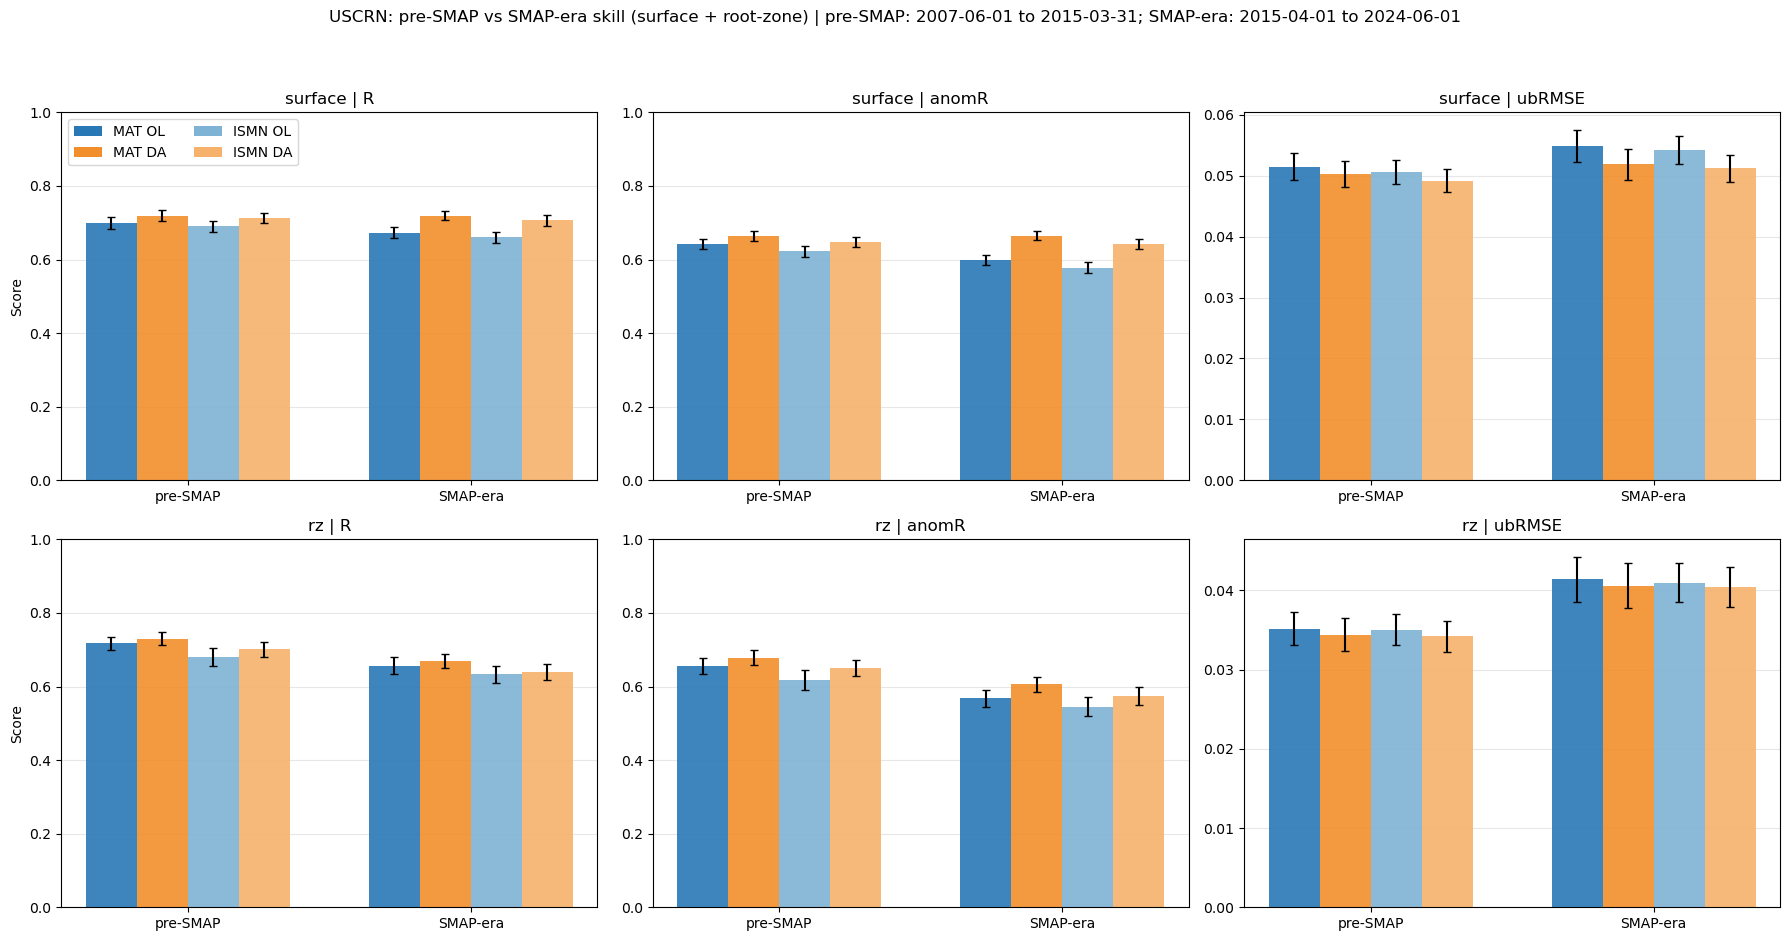

In [26]:
# -------------------------
# Plot summary comparison: surface (top) vs root-zone (bottom)
# Bars show MAT/ISMN x OL/DA for each period.
# -------------------------
from matplotlib.patches import Patch

domain_order = ["surface", "rz"]
metric_order = ["R", "anomR", "ubRMSE"]
range_names = [r[0] for r in RANGES]

bar_specs = [
    ("MAT", "OL", "#2878B5", "MAT OL"),
    ("MAT", "DA", "#F28E2B", "MAT DA"),
    ("ISMN", "OL", "#7FB3D5", "ISMN OL"),
    ("ISMN", "DA", "#F6B26B", "ISMN DA"),
]

fig, axs = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
bar_w = 0.18
x = np.arange(len(range_names))

for i, sm_domain in enumerate(domain_order):
    for j, metric in enumerate(metric_order):
        ax = axs[i, j]

        for k, (obs_source, exp, color, label) in enumerate(bar_specs):
            sub = summary_df[
                (summary_df["sm_domain"] == sm_domain)
                & (summary_df["obs_source"] == obs_source)
                & (summary_df["experiment"] == exp)
                & (summary_df["metric"] == metric)
            ].set_index("range").reindex(range_names)

            means = sub["mean"].to_numpy(dtype=float)
            sems = sub["sem"].to_numpy(dtype=float)

            ax.bar(
                x + (k - 1.5) * bar_w,
                means,
                width=bar_w,
                yerr=sems,
                capsize=3,
                label=label,
                color=color,
                alpha=0.9,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(range_names)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{sm_domain} | {metric}")
        if j == 0:
            ax.set_ylabel("Score")

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.0, 1.0)

legend_handles = [Patch(facecolor=c, label=l) for _, _, c, l in bar_specs]
axs[0, 0].legend(handles=legend_handles, loc="upper left", ncol=2)

pre_name, pre_start, pre_end = RANGES[0]
smap_name, smap_start, smap_end = RANGES[1]
fig.suptitle(
    f"{NETWORK}: pre-SMAP vs SMAP-era skill (surface + root-zone) | "
    f"{pre_name}: {pre_start} to {pre_end}; "
    f"{smap_name}: {smap_start} to {smap_end}",
    y=1.04,
)
plt.tight_layout()
plt.show()


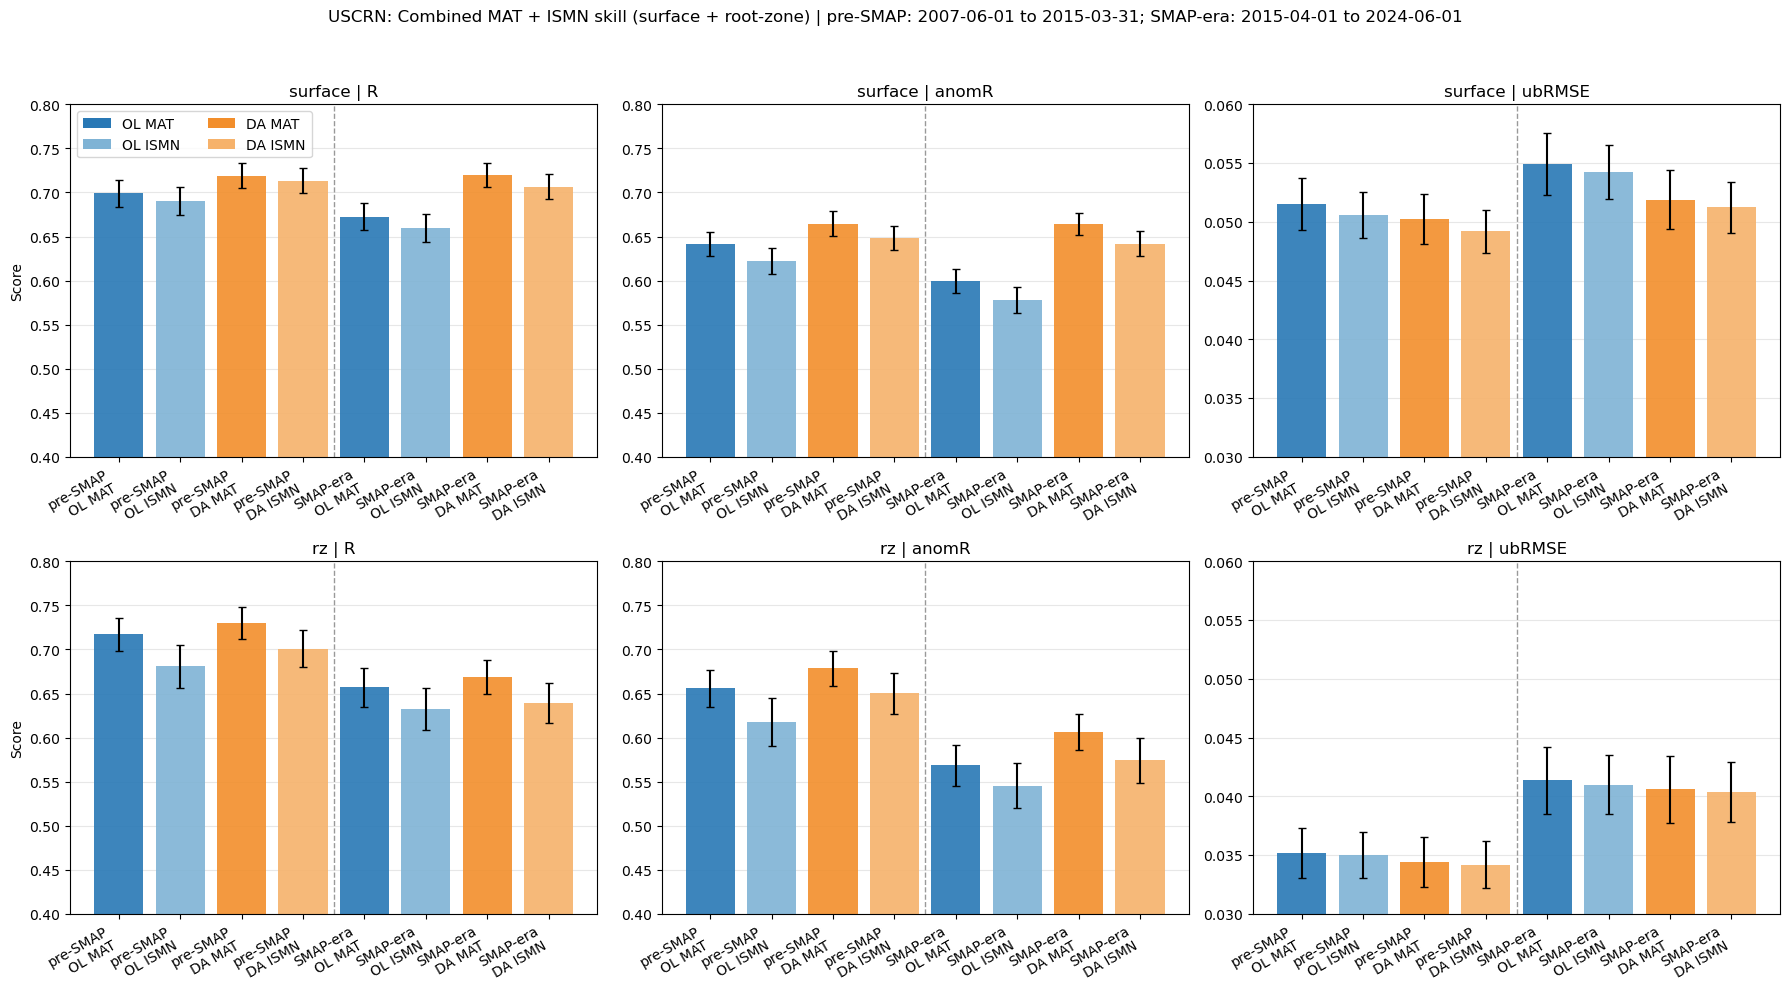

In [27]:
# -------------------------
# Plot combined MAT+ISMN summary (8 bars per metric) with two rows:
# surface (top), root-zone (bottom)
# -------------------------
if "summary_df" not in globals() or len(summary_df) == 0:
    raise RuntimeError("Run the summary stats cell first")

from matplotlib.patches import Patch

domain_order = ["surface", "rz"]
metric_order = ["R", "anomR", "ubRMSE"]
pre_name, pre_start, pre_end = RANGES[0]
smap_name, smap_start, smap_end = RANGES[1]

bar_specs = []
for rn in [pre_name, smap_name]:
    bar_specs.extend([
        {"range": rn, "experiment": "OL", "obs_source": "MAT", "label": f"{rn}\nOL MAT", "color": "#2878B5"},
        {"range": rn, "experiment": "OL", "obs_source": "ISMN", "label": f"{rn}\nOL ISMN", "color": "#7FB3D5"},
        {"range": rn, "experiment": "DA", "obs_source": "MAT", "label": f"{rn}\nDA MAT", "color": "#F28E2B"},
        {"range": rn, "experiment": "DA", "obs_source": "ISMN", "label": f"{rn}\nDA ISMN", "color": "#F6B26B"},
    ])

fig, axs = plt.subplots(2, 3, figsize=(18, 9.6), sharex=False)
x = np.arange(len(bar_specs))

for i, sm_domain in enumerate(domain_order):
    for j, metric in enumerate(metric_order):
        ax = axs[i, j]
        means = []
        sems = []
        colors = []
        labels = []

        for spec in bar_specs:
            row = summary_df[
                (summary_df["sm_domain"] == sm_domain)
                & (summary_df["range"] == spec["range"])
                & (summary_df["experiment"] == spec["experiment"])
                & (summary_df["obs_source"] == spec["obs_source"])
                & (summary_df["metric"] == metric)
            ]
            means.append(float(row["mean"].iloc[0]) if len(row) > 0 else np.nan)
            sems.append(float(row["sem"].iloc[0]) if len(row) > 0 else np.nan)
            colors.append(spec["color"])
            labels.append(spec["label"])

        ax.bar(
            x,
            means,
            yerr=sems,
            capsize=3,
            color=colors,
            alpha=0.9,
        )
        ax.axvline(3.5, color="0.6", lw=1, ls="--")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{sm_domain} | {metric}")
        if j == 0:
            ax.set_ylabel("Score")

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.4, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.06)

legend_handles = [
    Patch(facecolor="#2878B5", label="OL MAT"),
    Patch(facecolor="#7FB3D5", label="OL ISMN"),
    Patch(facecolor="#F28E2B", label="DA MAT"),
    Patch(facecolor="#F6B26B", label="DA ISMN"),
]
axs[0, 0].legend(handles=legend_handles, loc="upper left", ncol=2)

fig.suptitle(
    f"{NETWORK}: Combined MAT + ISMN skill (surface + root-zone) | "
    f"{pre_name}: {pre_start} to {pre_end}; "
    f"{smap_name}: {smap_start} to {smap_end}",
    y=1.03,
)
plt.tight_layout()
plt.show()


In [28]:
# -------------------------
# Site-level MAT-vs-ISMN deltas (ISMN - MAT) for each domain/experiment/range
# -------------------------
cmp_rows = []
for sm_domain in ["surface", "rz"]:
    for exp in EXP_ORDER:
        for rn, _, _ in range_bounds:
            sub = stats_df[
                (stats_df["sm_domain"] == sm_domain)
                & (stats_df["experiment"] == exp)
                & (stats_df["range"] == rn)
            ].copy()
            piv = sub.pivot_table(
                index=["site_index", "site_id", "station_name"],
                columns="obs_source",
                values=["R", "anomR", "ubRMSE"],
                aggfunc="first",
            )

            if ("R", "ISMN") in piv.columns and ("R", "MAT") in piv.columns:
                out = piv.copy()
                out[("dR", "ISMN-MAT")] = out[("R", "ISMN")] - out[("R", "MAT")]
                out[("danomR", "ISMN-MAT")] = out[("anomR", "ISMN")] - out[("anomR", "MAT")]
                out[("dubRMSE", "ISMN-MAT")] = out[("ubRMSE", "ISMN")] - out[("ubRMSE", "MAT")]
                out = out.reset_index()
                out["sm_domain"] = sm_domain
                out["experiment"] = exp
                out["range"] = rn
                cmp_rows.append(out)

if len(cmp_rows) > 0:
    site_cmp_df = pd.concat(cmp_rows, axis=0, ignore_index=True)
    display(site_cmp_df.head(20))
else:
    print("No site-level comparison rows available.")


site_index site_id           station_name         R            \
obs_source                                                ISMN       MAT   
0                   0   03047         Monahans-6-ENE  0.379877  0.349274   
1                   1   03048           Socorro-20-N  0.686706  0.690518   
2                   2   03054          Muleshoe-19-S  0.514772  0.542990   
3                   3   03055           Goodwell-2-E  0.539460  0.533057   
4                   7   03063        La-Junta-17-WSW  0.431181  0.385567   
5                   8   03067          Oakley-19-SSW  0.514394  0.555448   
6                   9   03072          Bronte-11-NNE  0.615367  0.613951   
7                  10   03074        Las-Cruces-20-N  0.740058  0.755662   
8                  11   03728    McClellanville-7-NE  0.748190  0.746956   
9                  13   03739     Cape-Charles-5-ENE  0.657900  0.645967   
10                 14   03758            Durham-11-W  0.764317  0.766145   
11                 15   03759  Charlottesville-2-SSE  0.726968  0.740127   
12                 20   04128           Riley-10-WSW  0.765276  0.755294   
13                 29   04222         Redding-12-WNW  0.852443  0.834044   
14                 31   04236       Corvallis-10-SSW  0.838689  0.857192   
15                 32   04237          Quinault-4-NE  0.847780  0.844516   
16                 35   12987        Edinburg-17-NNE  0.763644  0.767834   
17                 36   13301     Chillicothe-22-ENE  0.842352  0.857246   
18                 37   22016   Panther-Junction-2-N  0.677205  0.680185   
19                 38   23803      Holly-Springs-4-N  0.845105  0.853728   

               anomR              ubRMSE                  dR    danomR  \
obs_source      ISMN       MAT      ISMN       MAT  ISMN-MAT  ISMN-MAT   
0           0.329495  0.314451  0.021849  0.022732  0.030603  0.015044   
1           0.602815  0.604670  0.026302  0.026152 -0.003812 -0.001855   
2           0.481301  0.514705  0.046726  0.046628 -0.028218 -0.033404   
3           0.553082  0.562868  0.062485  0.061462  0.006403 -0.009786   
4           0.418779  0.371149  0.058642  0.056759  0.045614  0.047630   
5           0.556377  0.591268  0.066656  0.064157 -0.041055 -0.034891   
6           0.593630  0.596955  0.035959  0.036060  0.001415 -0.003326   
7           0.702615  0.698468  0.022335  0.022243 -0.015604  0.004148   
8           0.746172  0.746440  0.048293  0.048605  0.001234 -0.000267   
9           0.625408  0.636237  0.048434  0.048689  0.011933 -0.010829   
10          0.614379  0.637918  0.056679  0.056893 -0.001828 -0.023539   
11          0.623003  0.657527  0.063209  0.066377 -0.013159 -0.034524   
12          0.391536  0.476597  0.044696  0.037437  0.009981 -0.085061   
13          0.793126  0.800383  0.046135  0.047285  0.018399 -0.007257   
14          0.647406  0.638632  0.068987  0.073187 -0.018504  0.008774   
15          0.665832  0.671215  0.035910  0.037189  0.003264 -0.005384   
16          0.739662  0.744859  0.028983  0.028775 -0.004190 -0.005197   
17          0.795949  0.812537  0.063747  0.076885 -0.014894 -0.016589   
18          0.672679  0.675971  0.028451  0.028193 -0.002979 -0.003292   
19          0.675241  0.695079  0.054641  0.061188 -0.008623 -0.019839   

             dubRMSE sm_domain experiment     range  
obs_source  ISMN-MAT                                 
0          -0.000883   surface         OL  pre-SMAP  
1           0.000150   surface         OL  pre-SMAP  
2           0.000098   surface         OL  pre-SMAP  
3           0.001024   surface         OL  pre-SMAP  
4           0.001883   surface         OL  pre-SMAP  
5           0.002499   surface         OL  pre-SMAP  
6          -0.000101   surface         OL  pre-SMAP  
7           0.000092   surface         OL  pre-SMAP  
8          -0.000311   surface         OL  pre-SMAP  
9          -0.000255   surface         OL  pre-SMAP  
10         -0.000214   surface         OL  pre-SMAP  
11     

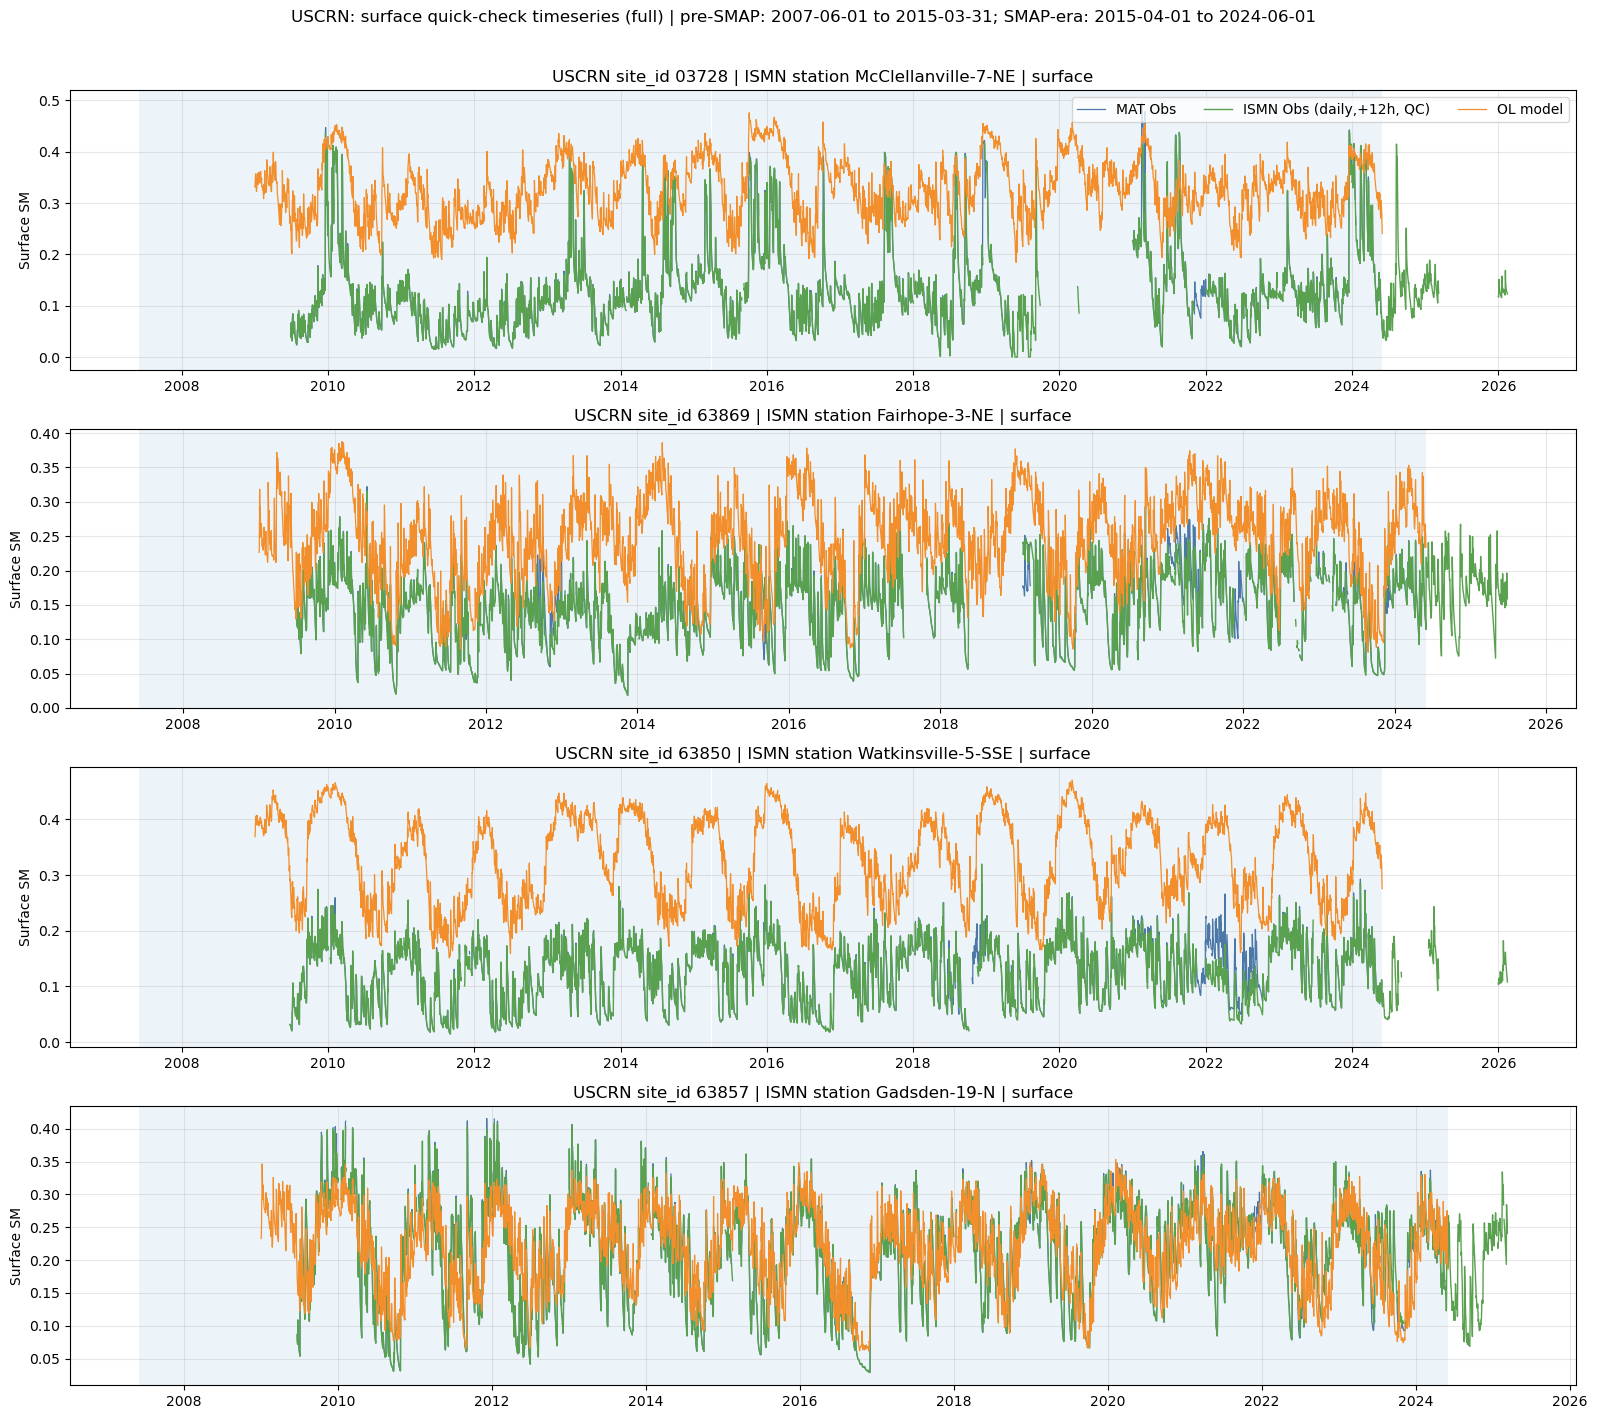

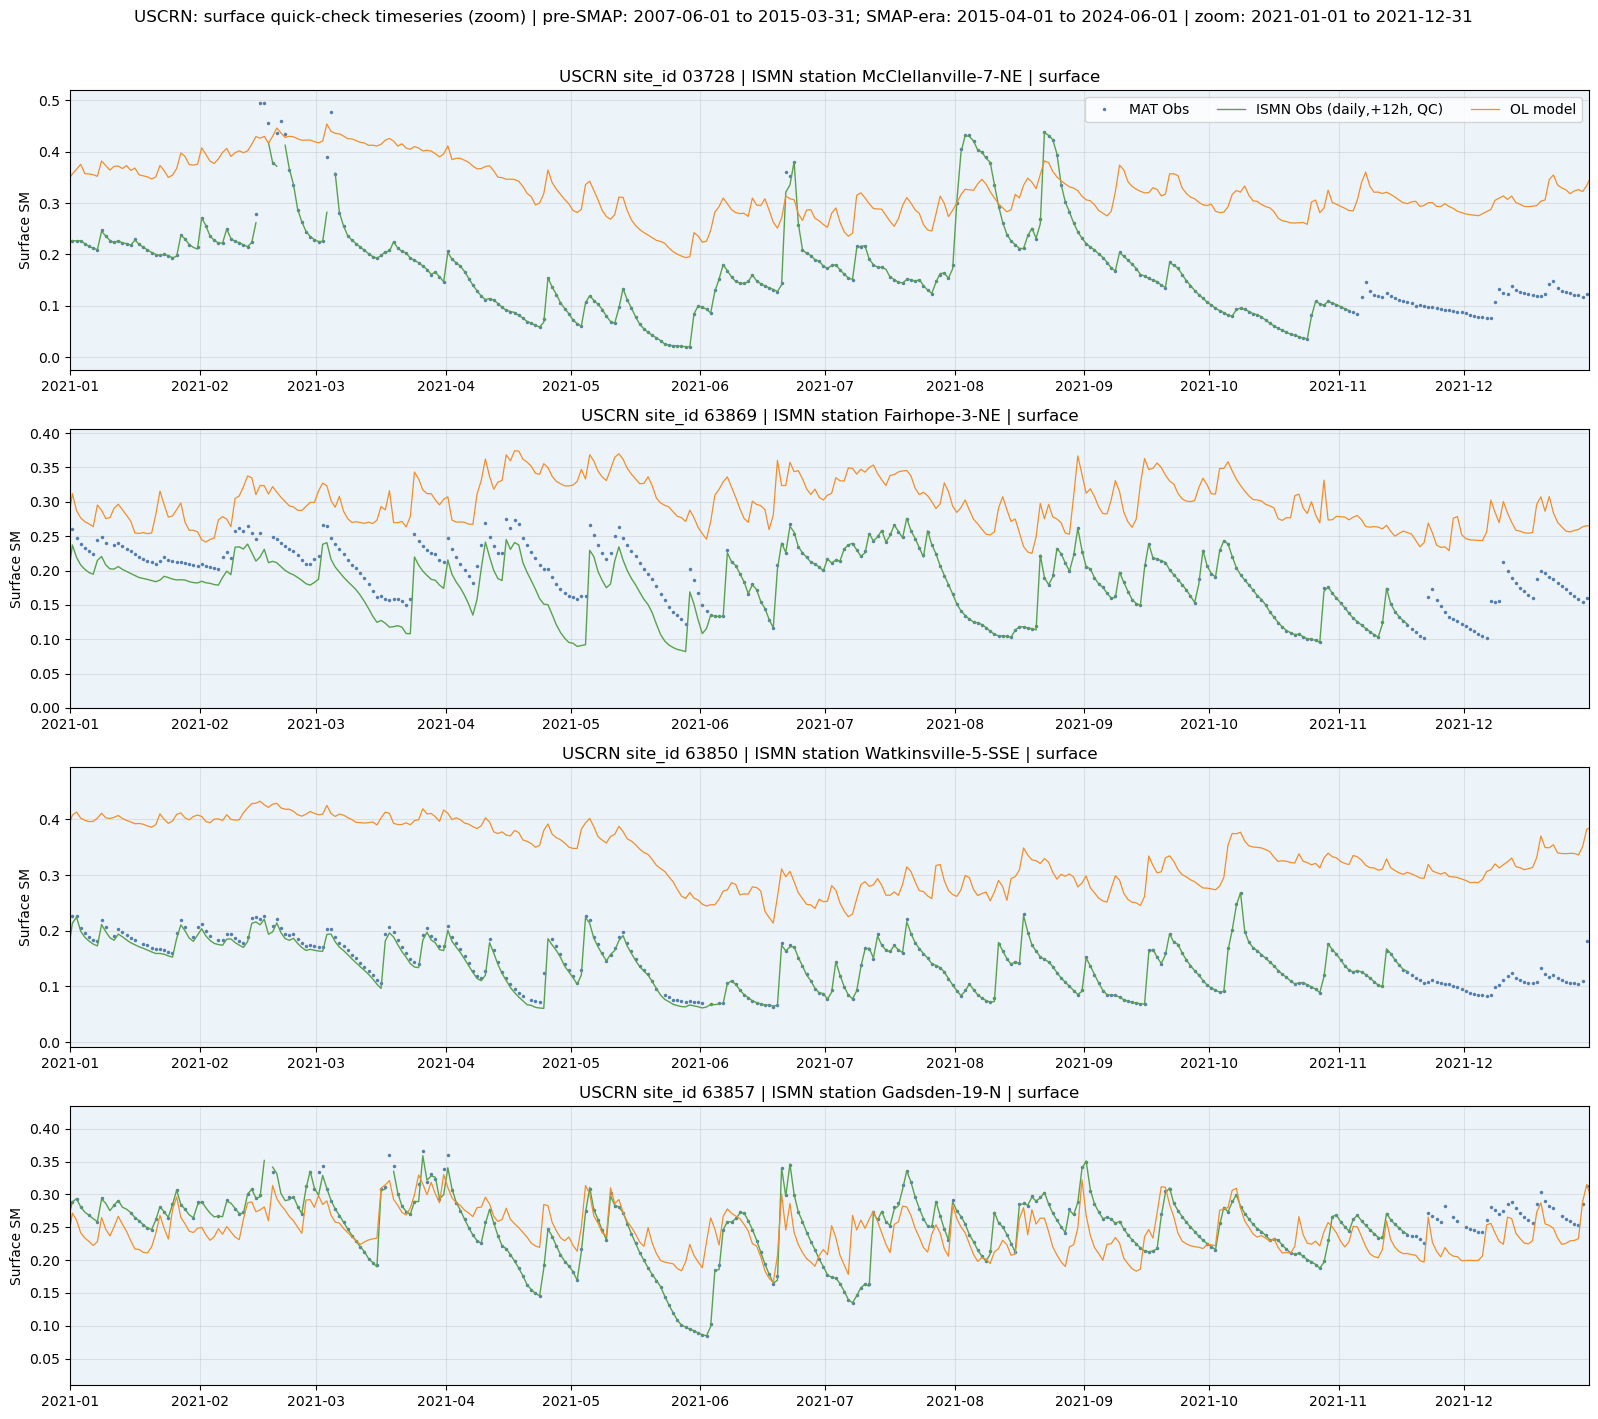

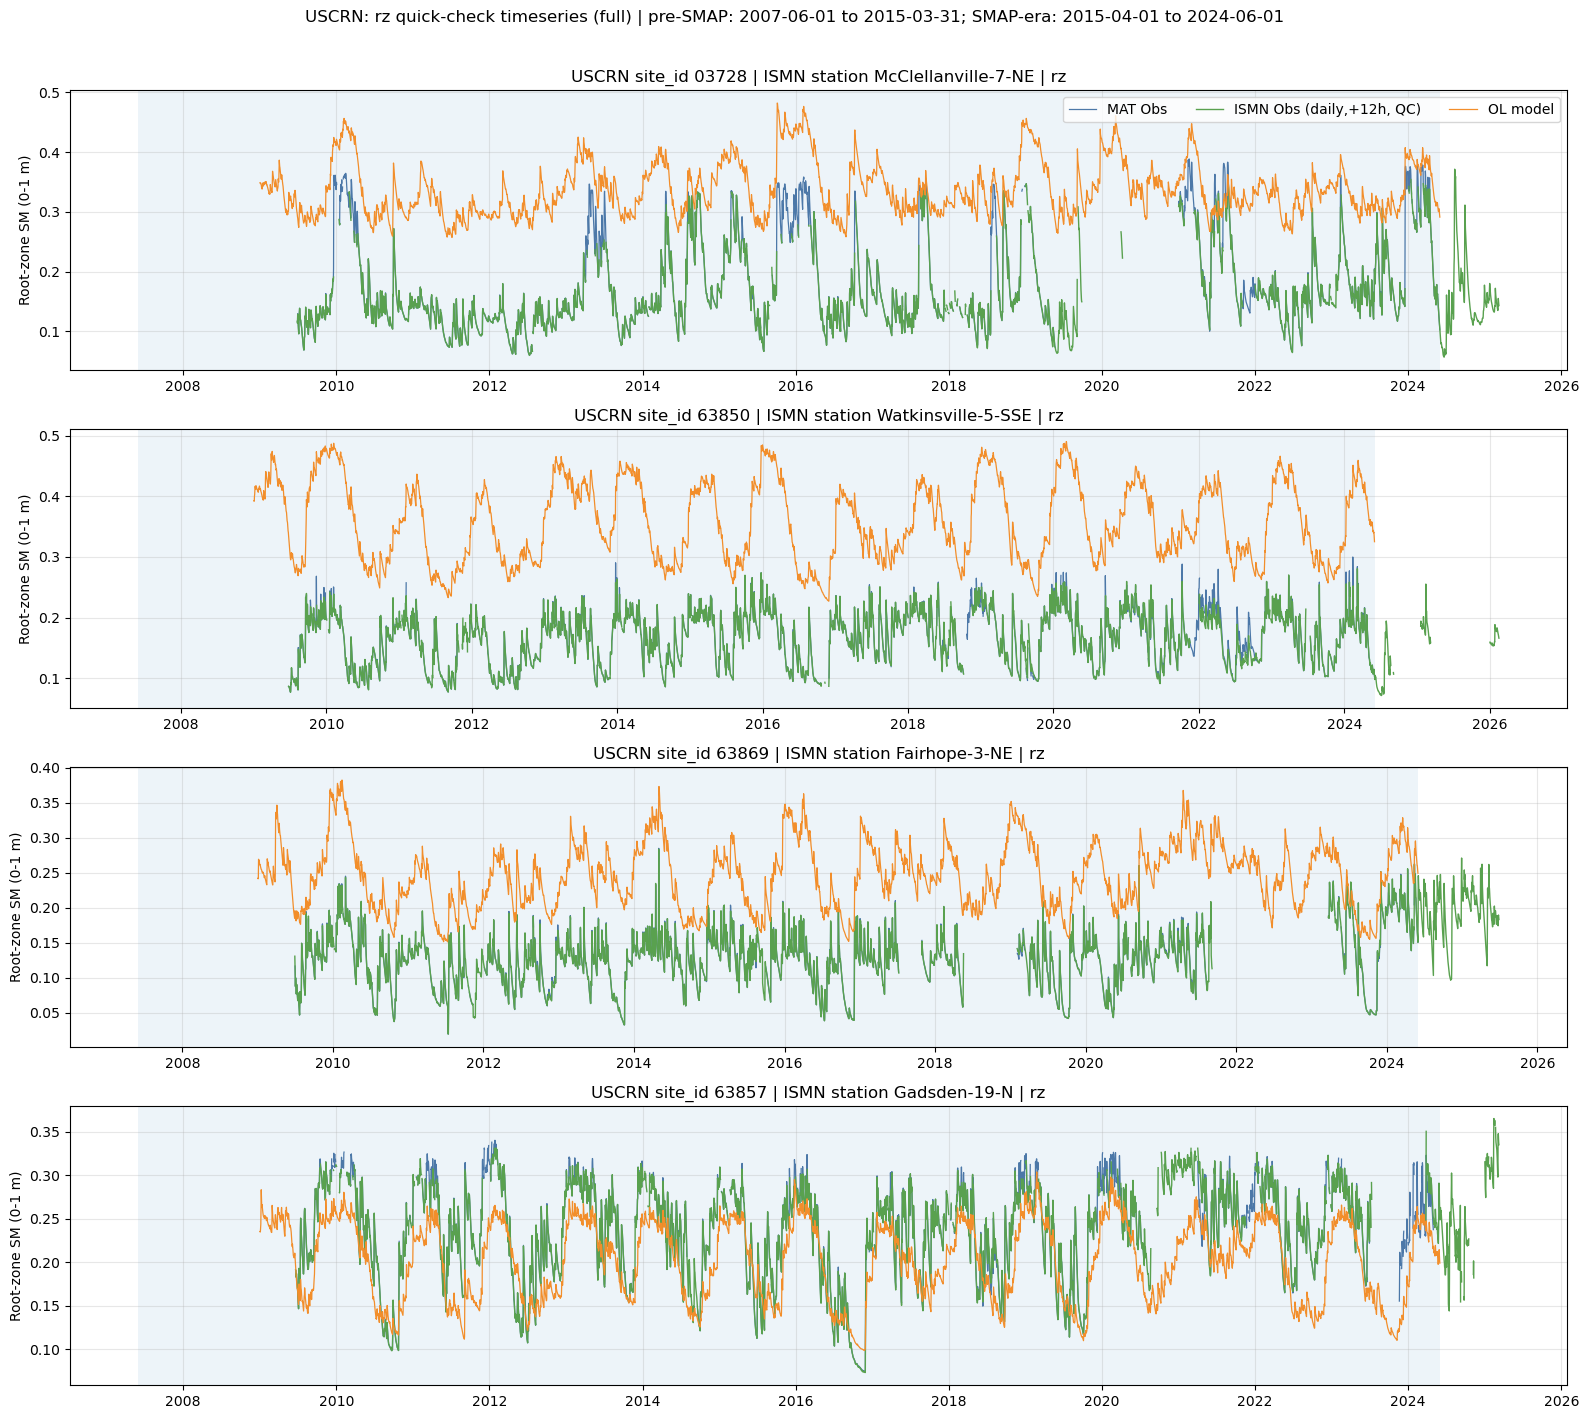

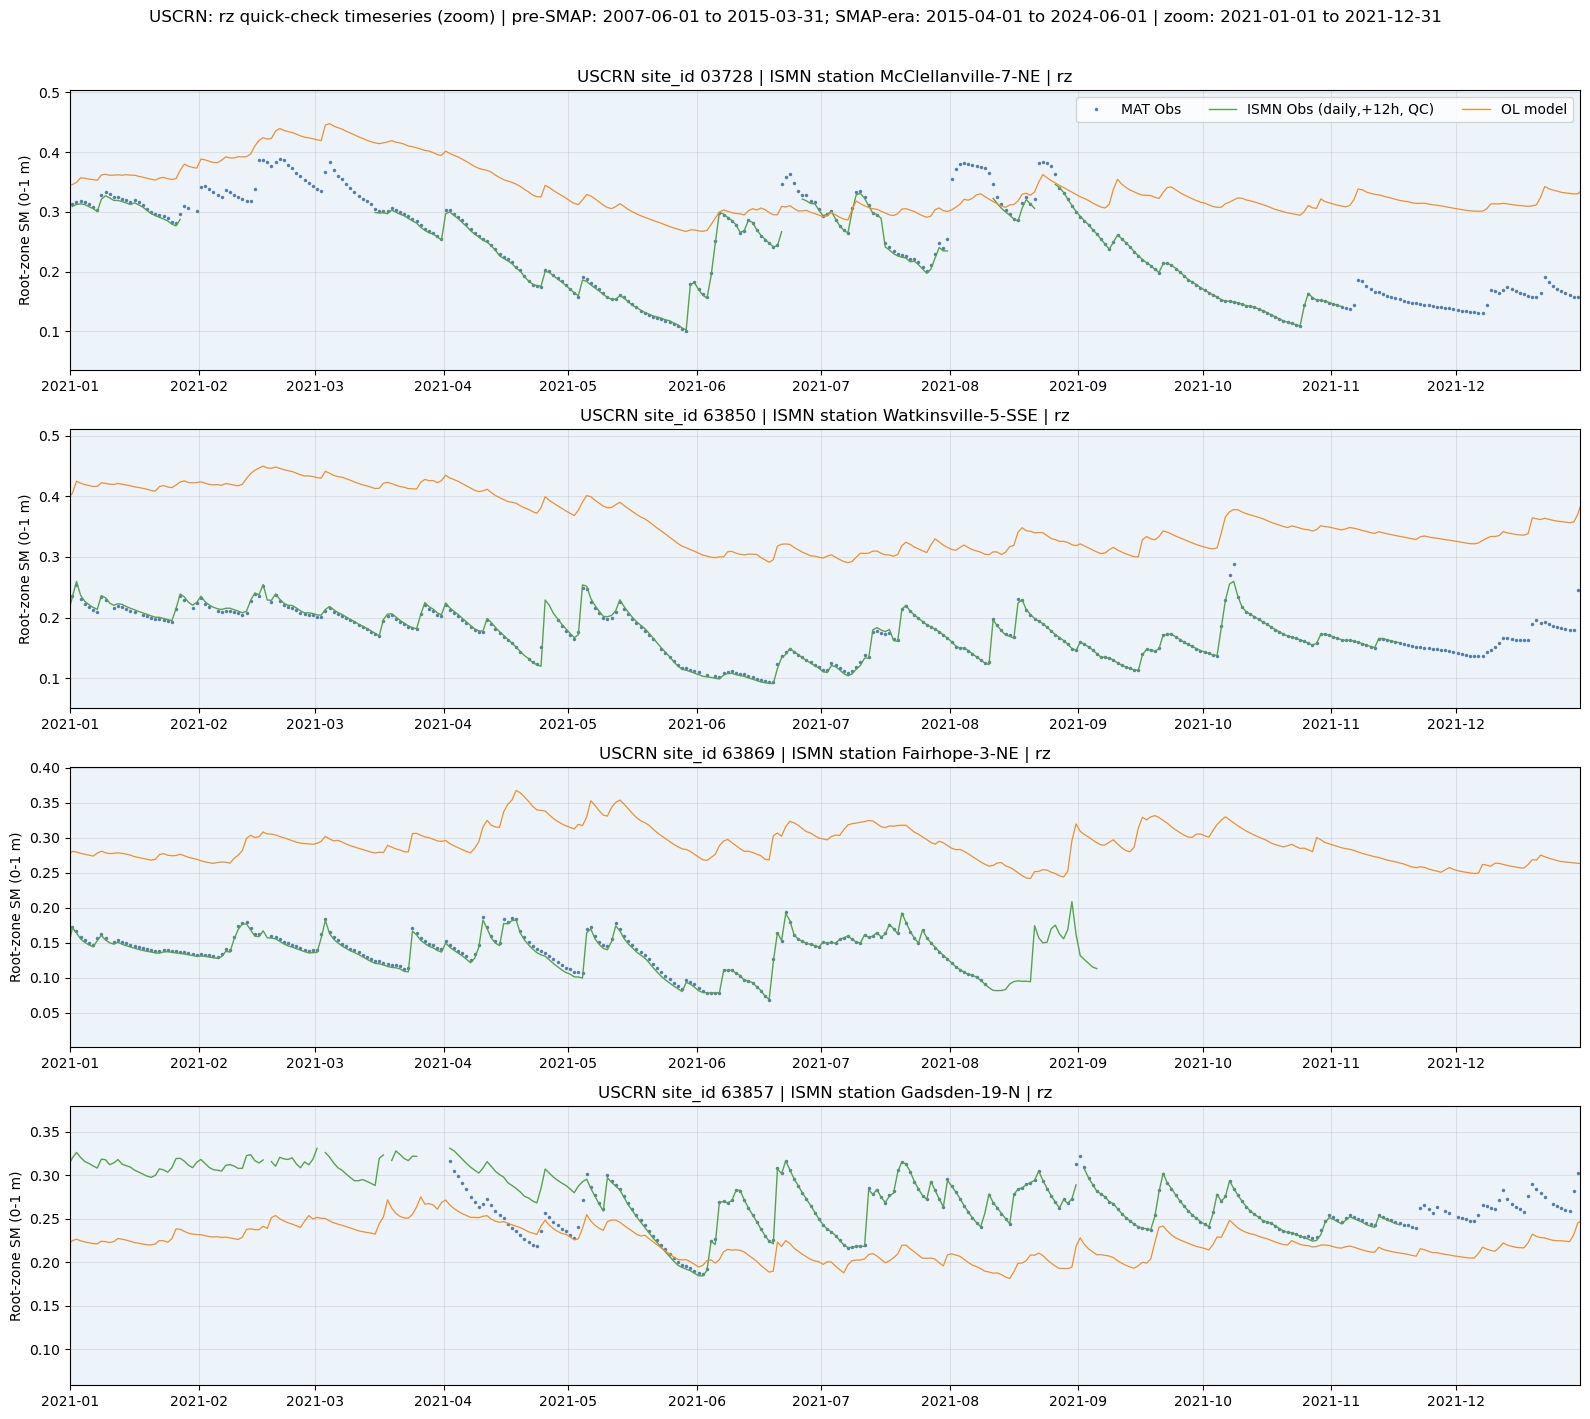

In [29]:
# -------------------------
# Quick time series checks (surface + root-zone; full + zoom)
# Uses domain-specific selected sites.
# -------------------------
if "selected_sites_by_domain" not in globals():
    if "selected_sites" in globals() and len(selected_sites) > 0:
        selected_sites_by_domain = {
            "surface": list(selected_sites),
            "rz": list(selected_sites),
        }
    else:
        raise RuntimeError("No selected sites to plot")

if max(len(selected_sites_by_domain.get("surface", [])), len(selected_sites_by_domain.get("rz", []))) == 0:
    raise RuntimeError("No selected sites to plot")

# User-controlled zoom window from config
zoom_start = pd.Timestamp(ZOOM_START)
zoom_end = pd.Timestamp(ZOOM_END)
if zoom_end < zoom_start:
    raise ValueError(f"ZOOM_END ({ZOOM_END}) is earlier than ZOOM_START ({ZOOM_START})")

plot_specs = [
    (
        "surface",
        mat_obs_surface_series_by_site,
        ismn_obs_surface_daily_by_site,
        model_surface_by_exp,
        "Surface SM",
    ),
    (
        "rz",
        mat_obs_rz_series_by_site,
        ismn_obs_rz_daily_by_site,
        model_rootzone_by_exp,
        "Root-zone SM (0-1 m)",
    ),
]


def _plot_domain_timeseries(sm_domain, mat_map, ismn_map, model_map, ylab, plot_sites_local, xlim=None, view_label="full"):
    if len(plot_sites_local) == 0:
        print(f"Skipping {sm_domain} {view_label}: no sites")
        return

    fig, axs = plt.subplots(len(plot_sites_local), 1, figsize=(16, 3.5 * len(plot_sites_local)), sharex=False)
    if len(plot_sites_local) == 1:
        axs = [axs]

    for ax, site in zip(axs, plot_sites_local):
        sid = meta["ids"][site] if site < len(meta["ids"]) else str(site)
        station_name = ismn_station_by_site[site]

        s_mat_obs = mat_map[site]
        s_ismn_daily = ismn_map[site]
        s_ol = pd.Series(model_map["OL"][:, site], index=mat_time).sort_index()

        if xlim is None:
            ax.plot(s_mat_obs.index, s_mat_obs.values, color="#4C78A8", lw=0.9, label="MAT Obs")
        else:
            ax.plot(
                s_mat_obs.index,
                s_mat_obs.values,
                linestyle="None",
                marker=".",
                ms=3.0,
                color="#4C78A8",
                alpha=0.9,
                label="MAT Obs",
            )
        ax.plot(s_ismn_daily.index, s_ismn_daily.values, color="#59A14F", lw=1.0, label="ISMN Obs (daily,+12h, QC)")
        ax.plot(s_ol.index, s_ol.values, color="#F28E2B", lw=0.9, label="OL model")

        ax.set_title(f"{NETWORK} site_id {sid} | ISMN station {station_name} | {sm_domain}")
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.3)

        for rn, t0, t1 in range_bounds:
            ax.axvspan(t0, t1, alpha=0.08)

        if xlim is not None:
            ax.set_xlim(xlim[0], xlim[1])

    axs[0].legend(loc="upper right", ncol=3)
    pre_name, pre_start, pre_end = RANGES[0]
    smap_name, smap_start, smap_end = RANGES[1]

    title = (
        f"{NETWORK}: {sm_domain} quick-check timeseries ({view_label}) | "
        f"{pre_name}: {pre_start} to {pre_end}; "
        f"{smap_name}: {smap_start} to {smap_end}"
    )
    if xlim is not None:
        title += f" | zoom: {xlim[0].date()} to {xlim[1].date()}"

    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


for sm_domain, mat_map, ismn_map, model_map, ylab in plot_specs:
    plot_sites = selected_sites_by_domain.get(sm_domain, [])[:4]

    _plot_domain_timeseries(
        sm_domain,
        mat_map,
        ismn_map,
        model_map,
        ylab,
        plot_sites_local=plot_sites,
        xlim=None,
        view_label="full",
    )

    _plot_domain_timeseries(
        sm_domain,
        mat_map,
        ismn_map,
        model_map,
        ylab,
        plot_sites_local=plot_sites,
        xlim=(zoom_start, zoom_end),
        view_label="zoom",
    )



In [30]:
# -------------------------
# Optional export
# -------------------------
out_tag = f"{NETWORK}_mat_vs_ismn_preSMAP_SMAPera_{SMAP_ERA_END.replace('-', '')}"
out_stats = BASE_DIR / f"{out_tag}_site_stats.csv"
out_summary = BASE_DIR / f"{out_tag}_summary.csv"
out_matches = BASE_DIR / f"{out_tag}_matches.csv"
out_cov = BASE_DIR / f"{out_tag}_site_coverage.csv"

stats_df.to_csv(out_stats, index=False)
summary_df.to_csv(out_summary, index=False)
match_df.to_csv(out_matches, index=False)
site_cov_df.to_csv(out_cov, index=False)

print("Wrote:")
print(f"  {out_stats}")
print(f"  {out_summary}")
print(f"  {out_matches}")
print(f"  {out_cov}")


Wrote:
  /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/USCRN_mat_vs_ismn_preSMAP_SMAPera_20240601_site_stats.csv
  /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/USCRN_mat_vs_ismn_preSMAP_SMAPera_20240601_summary.csv
  /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/USCRN_mat_vs_ismn_preSMAP_SMAPera_20240601_matches.csv
  /Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/USCRN_mat_vs_ismn_preSMAP_SMAPera_20240601_site_coverage.csv


In [31]:
# -------------------------
# ISMN-only site selection (no MAT-obs constraint), done separately for
# surface and root-zone so each domain is consistent across eras.
# -------------------------
TOP_N_ISMN_ONLY_SITES = None   # set None to use all eligible ISMN-only sites
MIN_ISMN_ONLY_DAYS_PER_RANGE = MIN_OBS_DAYS_PER_RANGE

if len(site_cov_df) == 0:
    raise RuntimeError("No matched sites with usable ISMN series available")

ismn_only_cov_df = site_cov_df.copy()
range_names = [rn for rn, _, _ in range_bounds]

for rn in range_names:
    ismn_only_cov_df[f"ok_ismn_surface_{rn}"] = ismn_only_cov_df[f"ismn_{rn}_count"] >= MIN_ISMN_ONLY_DAYS_PER_RANGE
    ismn_only_cov_df[f"ok_ismn_rz_{rn}"] = ismn_only_cov_df[f"ismn_rz_{rn}_count"] >= MIN_ISMN_ONLY_DAYS_PER_RANGE

surf_ok_cols = [f"ok_ismn_surface_{rn}" for rn in range_names]
rz_ok_cols = [f"ok_ismn_rz_{rn}" for rn in range_names]

ismn_only_cov_df["ismn_only_ok_surface"] = ismn_only_cov_df[surf_ok_cols].all(axis=1)
ismn_only_cov_df["ismn_only_ok_rz"] = ismn_only_cov_df[rz_ok_cols].all(axis=1)

surf_count_cols = [f"ismn_{rn}_count" for rn in range_names]
rz_count_cols = [f"ismn_rz_{rn}_count" for rn in range_names]

ismn_only_cov_df["ismn_surface_count_min"] = ismn_only_cov_df[surf_count_cols].min(axis=1)
ismn_only_cov_df["ismn_surface_count_total"] = ismn_only_cov_df[surf_count_cols].sum(axis=1)
ismn_only_cov_df["ismn_rz_count_min"] = ismn_only_cov_df[rz_count_cols].min(axis=1)
ismn_only_cov_df["ismn_rz_count_total"] = ismn_only_cov_df[rz_count_cols].sum(axis=1)

ismn_only_eligible_surface_df = (
    ismn_only_cov_df[ismn_only_cov_df["ismn_only_ok_surface"]]
    .copy()
    .sort_values(["ismn_surface_count_min", "ismn_surface_count_total"], ascending=[False, False])
)

ismn_only_eligible_rz_df = (
    ismn_only_cov_df[ismn_only_cov_df["ismn_only_ok_rz"]]
    .copy()
    .sort_values(["ismn_rz_count_min", "ismn_rz_count_total"], ascending=[False, False])
)

if TOP_N_ISMN_ONLY_SITES is not None:
    ismn_only_eligible_surface_df = ismn_only_eligible_surface_df.head(int(TOP_N_ISMN_ONLY_SITES)).copy()
    ismn_only_eligible_rz_df = ismn_only_eligible_rz_df.head(int(TOP_N_ISMN_ONLY_SITES)).copy()

ismn_only_sites_by_domain = {
    "surface": ismn_only_eligible_surface_df["site_index"].astype(int).tolist(),
    "rz": ismn_only_eligible_rz_df["site_index"].astype(int).tolist(),
}
ismn_only_sites = sorted(set(ismn_only_sites_by_domain["surface"]) | set(ismn_only_sites_by_domain["rz"]))

print(f"MIN_ISMN_ONLY_DAYS_PER_RANGE={MIN_ISMN_ONLY_DAYS_PER_RANGE}")
print(f"ISMN-only eligible sites (surface): {int(ismn_only_cov_df['ismn_only_ok_surface'].sum())} / {len(ismn_only_cov_df)}")
print(f"ISMN-only eligible sites (rz): {int(ismn_only_cov_df['ismn_only_ok_rz'].sum())} / {len(ismn_only_cov_df)}")
print(f"ISMN-only selected sites for surface stats: {len(ismn_only_sites_by_domain['surface'])}")
print(f"ISMN-only selected sites for rz stats: {len(ismn_only_sites_by_domain['rz'])}")

print("\nTop ISMN-only surface-eligible sites:")
display(ismn_only_eligible_surface_df.head(20))
print("\nTop ISMN-only root-zone-eligible sites:")
display(ismn_only_eligible_rz_df.head(20))



MIN_ISMN_ONLY_DAYS_PER_RANGE=1000
ISMN-only eligible sites (surface): 88 / 115
ISMN-only eligible sites (rz): 55 / 115
ISMN-only selected sites for surface stats: 88
ISMN-only selected sites for rz stats: 55

Top ISMN-only surface-eligible sites:


,site_index,site_id,station_name,distance_km,mat_pre-SMAP_count,ismn_pre-SMAP_count,mat_rz_pre-SMAP_count,ismn_rz_pre-SMAP_count,mat_SMAP-era_count,ismn_SMAP-era_count,...,ok_ismn_surface_pre-SMAP,ok_ismn_rz_pre-SMAP,ok_ismn_surface_SMAP-era,ok_ismn_rz_SMAP-era,ismn_only_ok_surface,ismn_only_ok_rz,ismn_surface_count_min,ismn_surface_count_total,ismn_rz_count_min,ismn_rz_count_total
78,11,03728,McClellanville-7-NE,0.495236,2050,2097,2050,1938,2656,2795,...,True,True,True,True,True,True,2097,4892,1938,4401
64,89,63869,Fairhope-3-NE,0.444267,1972,2087,1900,2087,2817,2863,...,True,True,True,True,True,True,2087,4950,2087,4492
57,84,63850,Watkinsville-5-SSE,0.413079,1927,2053,1919,2051,3133,3225,...,True,True,True,True,True,True,2053,5278,2051,5241
101,87,63857,Gadsden-19-N,0.578005,1883,2030,1836,1909,3043,3247,...,True,True,True,True,True,True,2030,5277,1909,4750
27,81,63831,Newton-5-ENE,0.246247,1437,1991,294,1510,3114,3164,...,True,True,True,True,True,True,1991,5155,1510,3591
26,58,53926,Stillwater-2-W,0.245863,1586,1941,719,1670,2456,3030,...,True,True,True,True,True,True,1941,4971,1571,3241
90,59,53927,Stillwater-5-WNW,0.536433,1639,1936,1611,1902,2835,3144,...,True,True,True,True,True,True,1936,5080,1902,4790
67,3,03055,Goodwell-2-E,0.453084,1508,1935,1493,1708,2047,2541,...,True,True,True,True,True,True,1935,4476,1708,3974
3,39,23904,Batesville-8-WNW,0.108766,1667,1906,1666,1829,2885,3184,...,True,True,True,True,True,True,1906,5090,1829,4399
49,60,53960,Lafayette-13-SE,0.359183,1804,1856,1405,1060,3207,3149,...,True,True,True,True,True,True,1856,5005,1060,3374



Top ISMN-only root-zone-eligible sites:


,site_index,site_id,station_name,distance_km,mat_pre-SMAP_count,ismn_pre-SMAP_count,mat_rz_pre-SMAP_count,ismn_rz_pre-SMAP_count,mat_SMAP-era_count,ismn_SMAP-era_count,...,ok_ismn_surface_pre-SMAP,ok_ismn_rz_pre-SMAP,ok_ismn_surface_SMAP-era,ok_ismn_rz_SMAP-era,ismn_only_ok_surface,ismn_only_ok_rz,ismn_surface_count_min,ismn_surface_count_total,ismn_rz_count_min,ismn_rz_count_total
64,89,63869,Fairhope-3-NE,0.444267,1972,2087,1900,2087,2817,2863,...,True,True,True,True,True,True,2087,4950,2087,4492
57,84,63850,Watkinsville-5-SSE,0.413079,1927,2053,1919,2051,3133,3225,...,True,True,True,True,True,True,2053,5278,2051,5241
78,11,03728,McClellanville-7-NE,0.495236,2050,2097,2050,1938,2656,2795,...,True,True,True,True,True,True,2097,4892,1938,4401
101,87,63857,Gadsden-19-N,0.578005,1883,2030,1836,1909,3043,3247,...,True,True,True,True,True,True,2030,5277,1909,4750
90,59,53927,Stillwater-5-WNW,0.536433,1639,1936,1611,1902,2835,3144,...,True,True,True,True,True,True,1936,5080,1902,4790
40,79,63828,Newton-8-W,0.305589,1634,1834,1552,1831,2367,2415,...,True,True,True,True,True,True,1834,4249,1831,4246
28,86,63856,Brunswick-23-S,0.247594,1592,1830,1591,1830,2870,2873,...,True,True,True,True,True,True,1830,4703,1830,4367
3,39,23904,Batesville-8-WNW,0.108766,1667,1906,1666,1829,2885,3184,...,True,True,True,True,True,True,1906,5090,1829,4399
59,80,63829,Newton-11-SW,0.419816,1744,1825,1625,1825,2069,1997,...,True,True,True,True,True,True,1825,3822,1825,3740
79,47,53136,Mercury-3-SSW,0.497601,1713,1818,1709,1818,2911,3079,...,True,True,True,True,True,True,1818,4897,1818,4897


In [32]:
# -------------------------
# Compute ISMN-only site-level stats (surface + root-zone): obs=ISMN daily, model=OL/DA
# using domain-specific selected site sets that are consistent across both eras.
# anomR climatology is computed over each full paired time series (all available years)
# -------------------------
if "ismn_only_sites_by_domain" not in globals():
    raise RuntimeError("Run the ISMN-only site selection cell first (ismn_only_sites_by_domain missing)")

if (len(ismn_only_sites_by_domain.get("surface", [])) == 0) and (len(ismn_only_sites_by_domain.get("rz", [])) == 0):
    raise RuntimeError("No ISMN-only selected sites. Lower MIN_ISMN_ONLY_DAYS_PER_RANGE or TOP_N_ISMN_ONLY_SITES.")

ismn_only_records = []
for sm_domain in ["surface", "rz"]:
    domain_sites = ismn_only_sites_by_domain.get(sm_domain, [])
    if len(domain_sites) == 0:
        print(f"Skipping ISMN-only {sm_domain}: no selected sites")
        continue

    for site in domain_sites:
        station_name = ismn_station_by_site[site]

        if sm_domain == "surface":
            obs_series = ismn_obs_surface_daily_by_site[site]
        elif sm_domain == "rz":
            obs_series = ismn_obs_rz_daily_by_site[site]
        else:
            raise ValueError(f"Unknown sm_domain: {sm_domain}")

        for exp in EXP_ORDER:
            if sm_domain == "surface":
                mod_series = pd.Series(model_surface_by_exp[exp][:, site], index=mat_time).sort_index()
            elif sm_domain == "rz":
                mod_series = pd.Series(model_rootzone_by_exp[exp][:, site], index=mat_time).sort_index()
            else:
                raise ValueError(f"Unknown sm_domain: {sm_domain}")

            # Full-record pairing for anomaly climatology
            pair_full = pd.concat([
                obs_series.rename("obs"),
                mod_series.rename("mod"),
            ], axis=1, join="inner").dropna()

            obs_anom_full = pd.Series(dtype=float)
            mod_anom_full = pd.Series(dtype=float)
            if len(pair_full) > 0:
                doy_full = pair_full.index.dayofyear.to_numpy(dtype=int)
                obs_anom_full = pd.Series(
                    compute_anom(pair_full["obs"].to_numpy(dtype=float), doy_full, Nmin_day=NMIN_DAY),
                    index=pair_full.index,
                )
                mod_anom_full = pd.Series(
                    compute_anom(pair_full["mod"].to_numpy(dtype=float), doy_full, Nmin_day=NMIN_DAY),
                    index=pair_full.index,
                )

            for rn, t0, t1 in range_bounds:
                obs_sub = obs_series[(obs_series.index >= t0) & (obs_series.index <= t1)]
                mod_sub = mod_series[(mod_series.index >= t0) & (mod_series.index <= t1)]

                if len(obs_anom_full) > 0:
                    obs_anom_sub = obs_anom_full[(obs_anom_full.index >= t0) & (obs_anom_full.index <= t1)]
                    mod_anom_sub = mod_anom_full[(mod_anom_full.index >= t0) & (mod_anom_full.index <= t1)]
                else:
                    obs_anom_sub = None
                    mod_anom_sub = None

                st = calc_pair_stats(
                    obs_sub,
                    mod_sub,
                    obs_anom_series=obs_anom_sub,
                    mod_anom_series=mod_anom_sub,
                )

                ismn_only_records.append({
                    "site_index": site,
                    "site_id": meta["ids"][site] if site < len(meta["ids"]) else np.nan,
                    "station_name": station_name,
                    "sm_domain": sm_domain,
                    "experiment": exp,
                    "range": rn,
                    "N_pairs": st["N_pairs"],
                    "R": st["R"],
                    "anomR": st["anomR"],
                    "ubRMSE": st["ubRMSE"],
                })

ismn_only_stats_df = pd.DataFrame(ismn_only_records)

# Aggregate summary with enforced identical site membership across eras for each metric.
summary_rows = []
range_names = [rn for rn, _, _ in range_bounds]
for sm_domain in ["surface", "rz"]:
    for exp in EXP_ORDER:
        combo = ismn_only_stats_df[
            (ismn_only_stats_df["sm_domain"] == sm_domain)
            & (ismn_only_stats_df["experiment"] == exp)
        ]

        for metric in ["R", "anomR", "ubRMSE"]:
            piv = combo.pivot_table(
                index="site_index",
                columns="range",
                values=metric,
                aggfunc="first",
            ).reindex(columns=range_names)

            if len(piv) > 0:
                common_mask = piv.notna().all(axis=1)
                piv_common = piv.loc[common_mask]
                n_common = int(common_mask.sum())
            else:
                piv_common = piv
                n_common = 0

            for rn in range_names:
                vals = piv_common[rn].to_numpy(dtype=float) if rn in piv_common.columns else np.array([], dtype=float)
                n = int(np.sum(np.isfinite(vals)))
                mean = float(np.nanmean(vals)) if n > 0 else np.nan
                sem = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
                summary_rows.append({
                    "sm_domain": sm_domain,
                    "experiment": exp,
                    "range": rn,
                    "metric": metric,
                    "n_sites": n,
                    "n_sites_common_across_ranges": n_common,
                    "site_set_rule": "finite_metric_in_all_ranges",
                    "mean": mean,
                    "sem": sem,
                })

ismn_only_summary_df = pd.DataFrame(summary_rows)

# Diagnostic check: for each (domain, experiment, metric), n_sites should match across ranges.
n_check = ismn_only_summary_df.pivot_table(
    index=["sm_domain", "experiment", "metric"],
    columns="range",
    values="n_sites",
    aggfunc="first",
)
bad = n_check.nunique(axis=1) > 1
if bad.any():
    print("WARNING: inconsistent ISMN-only n_sites across ranges for some combinations:")
    display(n_check[bad].reset_index())
else:
    print("Verified: ISMN-only n_sites is identical across ranges for every domain/experiment/metric.")

print(f"Computed ISMN-only rows: {len(ismn_only_stats_df)}")
display(ismn_only_summary_df.head(24))



Verified: ISMN-only n_sites is identical across ranges for every domain/experiment/metric.
Computed ISMN-only rows: 572


,sm_domain,experiment,range,metric,n_sites,n_sites_common_across_ranges,site_set_rule,mean,sem
0,surface,OL,pre-SMAP,R,88,88,finite_metric_in_all_ranges,0.673940,0.014174
1,surface,OL,SMAP-era,R,88,88,finite_metric_in_all_ranges,0.653660,0.013385
2,surface,OL,pre-SMAP,anomR,88,88,finite_metric_in_all_ranges,0.606965,0.013018
3,surface,OL,SMAP-era,anomR,88,88,finite_metric_in_all_ranges,0.567195,0.012423
4,surface,OL,pre-SMAP,ubRMSE,88,88,finite_metric_in_all_ranges,0.051243,0.001664
5,surface,OL,SMAP-era,ubRMSE,88,88,finite_metric_in_all_ranges,0.053883,0.001858
6,surface,DA,pre-SMAP,R,88,88,finite_metric_in_all_ranges,0.708928,0.012243
7,surface,DA,SMAP-era,R,88,88,finite_metric_in_all_ranges,0.707580,0.011763
8,surface,DA,pre-SMAP,anomR,88,88,finite_metric_in_all_ranges,0.643216,0.011675
9,surface,DA,SMAP-era,anomR,88,88,finite_metric_in_all_ranges,0.636013,0.012246


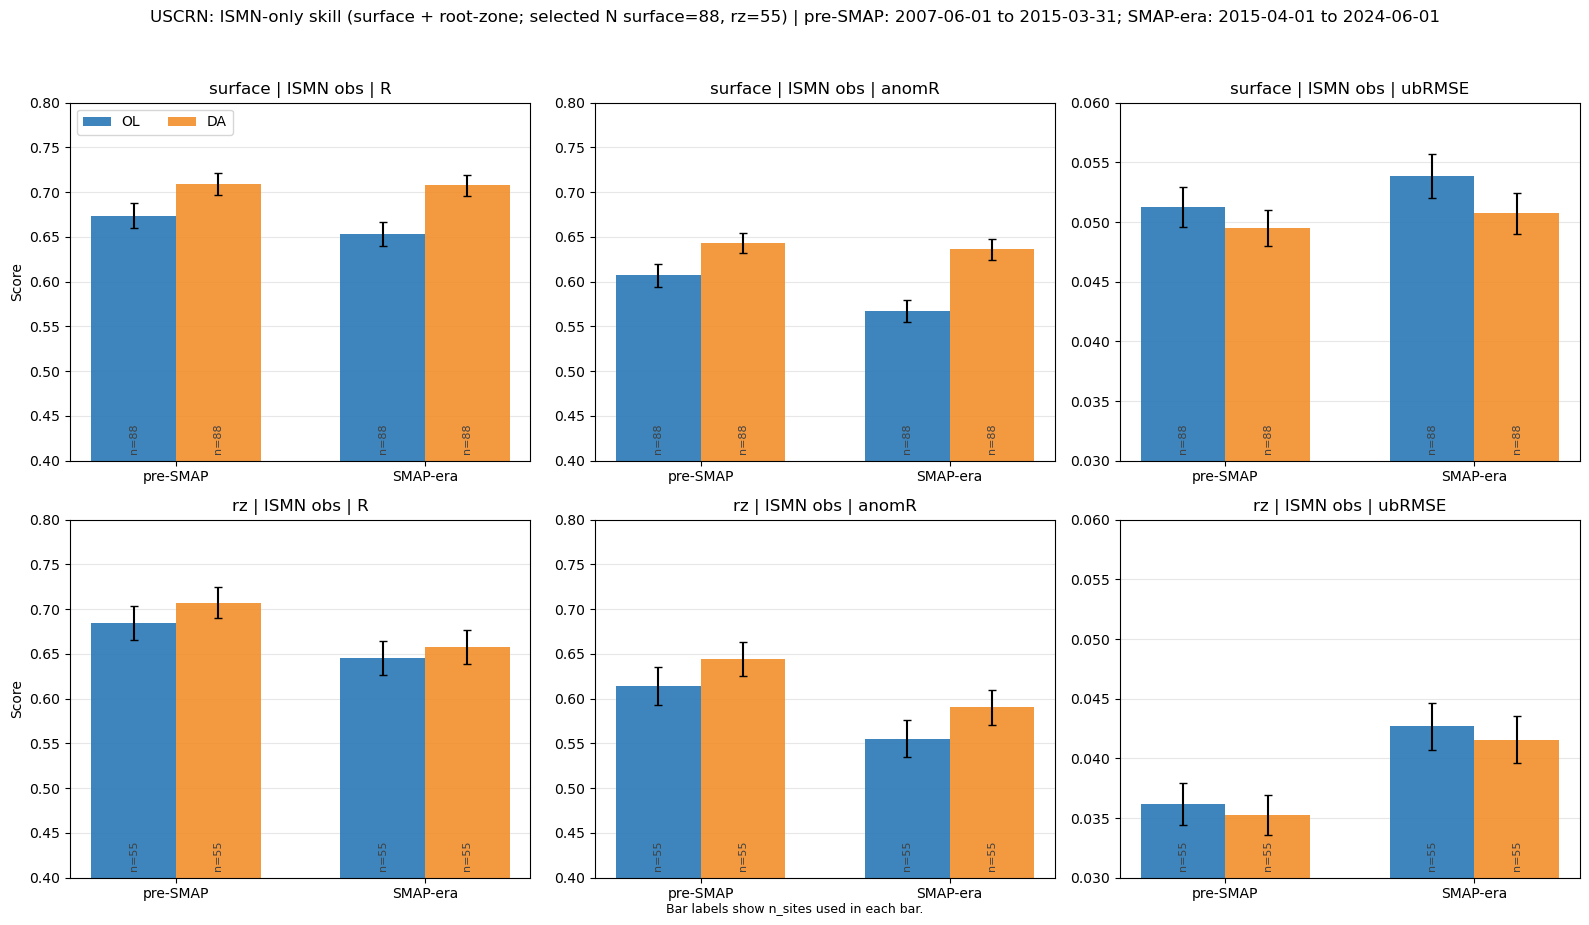

In [33]:
# -------------------------
# Plot ISMN-only summary (OL vs DA across periods) with two rows:
# surface (top), root-zone (bottom)
# -------------------------
if "ismn_only_summary_df" not in globals() or len(ismn_only_summary_df) == 0:
    raise RuntimeError("Run the ISMN-only stats cell first")

metric_order = ["R", "anomR", "ubRMSE"]
domain_order = ["surface", "rz"]
range_names = [r[0] for r in RANGES]
colors = {"OL": "#2878B5", "DA": "#F28E2B"}

fig, axs = plt.subplots(2, 3, figsize=(16, 8.8), sharex=False)
bar_w = 0.34
x = np.arange(len(range_names))

for i, sm_domain in enumerate(domain_order):
    for j, metric in enumerate(metric_order):
        ax = axs[i, j]
        n_by_exp = {}

        for k, exp in enumerate(EXP_ORDER):
            sub = ismn_only_summary_df[
                (ismn_only_summary_df["sm_domain"] == sm_domain)
                & (ismn_only_summary_df["experiment"] == exp)
                & (ismn_only_summary_df["metric"] == metric)
            ].set_index("range").reindex(range_names)

            means = sub["mean"].to_numpy(dtype=float)
            sems = sub["sem"].to_numpy(dtype=float)
            nvals = sub["n_sites"].to_numpy(dtype=float)
            n_by_exp[exp] = nvals

            ax.bar(
                x + (k - 0.5) * bar_w,
                means,
                width=bar_w,
                yerr=sems,
                capsize=3,
                label=exp,
                color=colors[exp],
                alpha=0.9,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(range_names)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.set_title(f"{sm_domain} | ISMN obs | {metric}")
        if j == 0:
            ax.set_ylabel("Score")

        if metric in ["R", "anomR"]:
            ax.set_ylim(0.4, 0.8)
        elif metric == "ubRMSE":
            ax.set_ylim(0.03, 0.06)

        # Annotate each bar with the actual number of sites used in that statistic.
        ymin, ymax = ax.get_ylim()
        ytxt = ymin + 0.02 * (ymax - ymin)
        for k, exp in enumerate(EXP_ORDER):
            xpos = x + (k - 0.5) * bar_w
            nvals = n_by_exp.get(exp, np.full_like(x, np.nan, dtype=float))
            for xx, nn in zip(xpos, nvals):
                if np.isfinite(nn):
                    ax.text(
                        xx,
                        ytxt,
                        f"n={int(nn)}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        rotation=90,
                        color="0.25",
                    )

axs[0, 0].legend(loc="upper left", ncol=2)
pre_name, pre_start, pre_end = RANGES[0]
smap_name, smap_start, smap_end = RANGES[1]
n_surface_sel = len(ismn_only_sites_by_domain.get("surface", [])) if "ismn_only_sites_by_domain" in globals() else np.nan
n_rz_sel = len(ismn_only_sites_by_domain.get("rz", [])) if "ismn_only_sites_by_domain" in globals() else np.nan
fig.suptitle(
    f"{NETWORK}: ISMN-only skill (surface + root-zone; selected N surface={n_surface_sel}, rz={n_rz_sel}) | "
    f"{pre_name}: {pre_start} to {pre_end}; "
    f"{smap_name}: {smap_start} to {smap_end}",
    y=1.03,
)
fig.text(0.5, 0.005, "Bar labels show n_sites used in each bar.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()



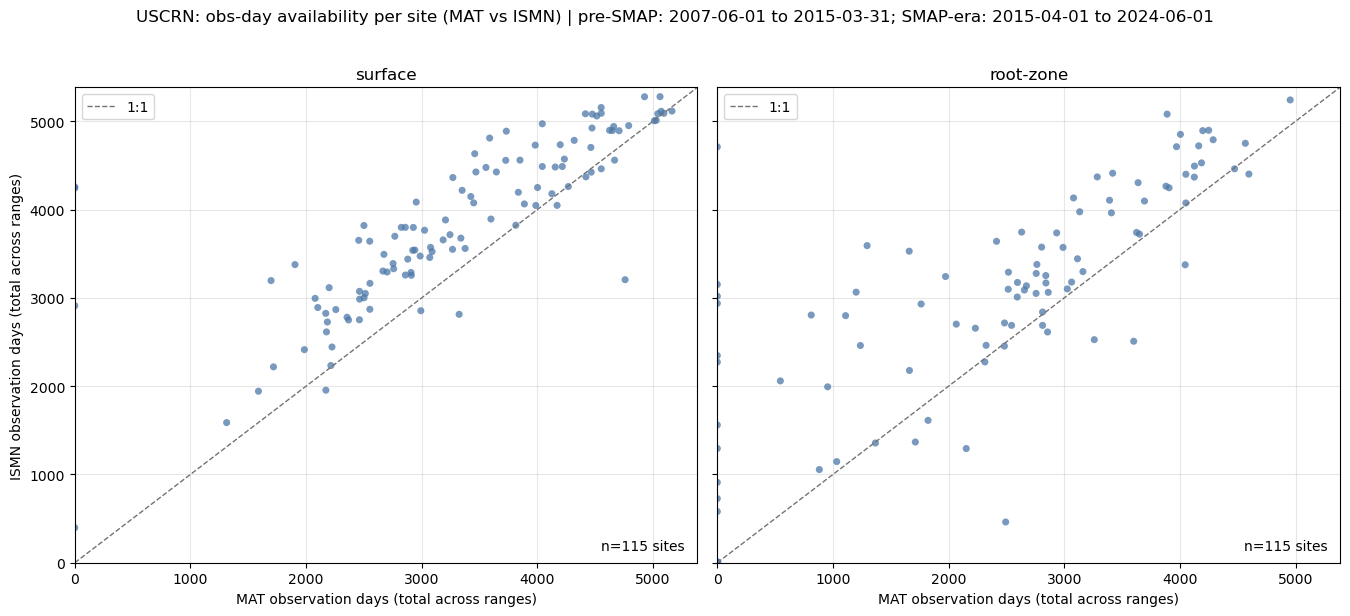

In [34]:
# -------------------------
# Scatter: number of observation days per site (MAT vs ISMN)
# 1x2 panel: surface (left) and root-zone (right)
# -------------------------
if "site_cov_df" not in globals() or len(site_cov_df) == 0:
    raise RuntimeError("site_cov_df is missing or empty. Run site-series/coverage cells first.")

range_names = [r[0] for r in RANGES]


def _build_total_day_counts(df, mat_prefix, ismn_prefix):
    mat_cols = [f"{mat_prefix}_{rn}_count" for rn in range_names]
    ismn_cols = [f"{ismn_prefix}_{rn}_count" for rn in range_names]

    missing = [c for c in (mat_cols + ismn_cols) if c not in df.columns]
    if len(missing) > 0:
        raise KeyError(f"Missing expected coverage columns: {missing}")

    out = df[["site_index", "site_id", "station_name"]].copy()
    out["mat_days_total"] = df[mat_cols].sum(axis=1, min_count=1)
    out["ismn_days_total"] = df[ismn_cols].sum(axis=1, min_count=1)
    return out


surface_days_df = _build_total_day_counts(site_cov_df, mat_prefix="mat", ismn_prefix="ismn")
rz_days_df = _build_total_day_counts(site_cov_df, mat_prefix="mat_rz", ismn_prefix="ismn_rz")

surf_valid = np.isfinite(surface_days_df["mat_days_total"].to_numpy(dtype=float)) & np.isfinite(surface_days_df["ismn_days_total"].to_numpy(dtype=float))
rz_valid = np.isfinite(rz_days_df["mat_days_total"].to_numpy(dtype=float)) & np.isfinite(rz_days_df["ismn_days_total"].to_numpy(dtype=float))

surf = surface_days_df.loc[surf_valid].copy()
rz = rz_days_df.loc[rz_valid].copy()

all_vals = np.r_[
    surf["mat_days_total"].to_numpy(dtype=float),
    surf["ismn_days_total"].to_numpy(dtype=float),
    rz["mat_days_total"].to_numpy(dtype=float),
    rz["ismn_days_total"].to_numpy(dtype=float),
]
maxv = float(np.nanmax(all_vals)) if all_vals.size > 0 else 1.0
upper = maxv * 1.02

fig, axs = plt.subplots(1, 2, figsize=(13.6, 6.0), sharex=True, sharey=True)

panel_specs = [
    (axs[0], surf, "surface"),
    (axs[1], rz, "root-zone"),
]

for ax, sub, domain_label in panel_specs:
    x = sub["mat_days_total"].to_numpy(dtype=float)
    y = sub["ismn_days_total"].to_numpy(dtype=float)

    ax.scatter(x, y, s=26, alpha=0.75, edgecolor="none", color="#4C78A8")
    ax.plot([0, upper], [0, upper], ls="--", lw=1.0, color="0.45", label="1:1")
    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_title(domain_label)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left")

    ax.text(
        0.98,
        0.02,
        f"n={len(sub)} sites",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
    )

axs[0].set_ylabel("ISMN observation days (total across ranges)")
for ax in axs:
    ax.set_xlabel("MAT observation days (total across ranges)")

range_txt = "; ".join([f"{name}: {start} to {end}" for name, start, end in RANGES])
fig.suptitle(
    f"{NETWORK}: obs-day availability per site (MAT vs ISMN) | {range_txt}",
    y=1.02,
)
plt.tight_layout()
plt.show()


